# HHGNN-Fuzzy V2 Pipeline for Credit Rating Prediction

Enhanced notebook implementing **Hierarchical Heterogeneous Graph Neural Network V2** with **Focal + Ordinal Hybrid Loss**, **Fuzzy Graph Construction**, and **SHAP Explainability** for ordinal corporate credit rating.

## Key Improvements over V1
| Component | V1 | V2 |
|---|---|---|
| **Loss** | FuzzyFocalLoss (CE) | **Focal + Ordinal Hybrid** |
| **Node features** | 2D [value, pos] | **4D [value, pos, z_score, rank]** |
| **Hidden channels** | 64 | **128** |
| **GAT layers** | 2 | **3** |
| **Attention heads** | 4 | **8** |
| **Fuzzy integration** | Loss weighting | **Architectural Fuzzy Gate** |
| **Scheduler** | OneCycleLR | **CosineAnnealingWarmRestarts** |
| **Metrics** | Acc, F1, AUC | + **QWK, Adjacent Acc, MAE** |

**Kaggle Ready** | GPU Optimized | Ordinal Credit Rating

## 1. Environment Setup & Dependencies


In [1]:
import platform
import sys
from pathlib import Path

IN_KAGGLE = Path('/kaggle').exists()
WORKING_DIR = Path('/kaggle/working') if IN_KAGGLE else Path('.')
ARTIFACT_DIR = WORKING_DIR / 'credit_rating_artifacts'
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

print('Python:', platform.python_version())
print('Running on Kaggle:', IN_KAGGLE)
print('Working directory:', WORKING_DIR.resolve())
print('Artifact directory:', ARTIFACT_DIR.resolve())

Python: 3.12.12
Running on Kaggle: True
Working directory: /kaggle/working
Artifact directory: /kaggle/working/credit_rating_artifacts


In [2]:
# ============================================================
# Install PyTorch Geometric + SHAP (Kaggle Compatible)
# ============================================================

import sys, subprocess, torch, os

IN_KAGGLE = 'KAGGLE_KERNEL_RUN_TYPE' in os.environ or Path('/kaggle').exists()

print(f"Environment: {'Kaggle' if IN_KAGGLE else 'Local'}")
print(f"PyTorch: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"CUDA version: {torch.version.cuda}")

torch_version = torch.__version__.split('+')[0]
torch_suffix = torch.__version__.split('+')[1] if '+' in torch.__version__ else 'cpu'
wheel_url = f"https://data.pyg.org/whl/torch-{torch_version}+{torch_suffix}.html"

print(f"Installing PyTorch Geometric for torch {torch_version}+{torch_suffix}...")
try:
    if IN_KAGGLE:
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'torch-geometric', '-f', wheel_url, '-q'])
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'torch-scatter', 'torch-sparse', '-f', wheel_url, '-q'])
    else:
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'torch-geometric', 'torch-scatter', 'torch-sparse', '-q'])
    print("PyTorch Geometric installed successfully")
except Exception as e:
    print(f"Installation failed: {e}")
    try:
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'torch-geometric', '-q'])
        print("PyTorch Geometric installed (minimal)")
    except Exception as e2:
        print(f"Fallback also failed: {e2}")

# Install SHAP
try:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'shap', '-q'])
    print("SHAP installed successfully")
except Exception as e:
    print(f"SHAP installation failed: {e}")

# Verify
import torch_geometric
from torch_geometric.data import Data, Batch
from torch_geometric.nn import GATConv, global_mean_pool, global_max_pool
print(f"PyTorch Geometric: {torch_geometric.__version__}")

import shap
print(f"SHAP: {shap.__version__}")
print("All dependencies verified!")

Environment: Kaggle
PyTorch: 2.9.0+cu126
CUDA available: True
CUDA version: 12.6
Installing PyTorch Geometric for torch 2.9.0+cu126...
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 53.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 16.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 96.4 MB/s eta 0:00:00
PyTorch Geometric installed successfully
SHAP installed successfully
PyTorch Geometric: 2.7.0
SHAP: 0.50.0
All dependencies verified!


## 2. Data Loading & EDA


In [3]:
import random, math, warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import rankdata

from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    confusion_matrix, classification_report, cohen_kappa_score
)
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import LabelEncoder, label_binarize, RobustScaler
from sklearn.metrics.pairwise import cosine_similarity as sklearn_cosine_similarity

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from torch_geometric.data import Data, Batch
from torch_geometric.loader import DataLoader as PyGDataLoader
from torch_geometric.nn import GATConv, global_mean_pool, global_max_pool

import shap
import networkx as nx

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)


Using device: cuda


In [4]:
TRAIN_PATH = '/kaggle/input/datasets/tailength/corporate-credit-rating/train_augmented_timegan.csv'
VAL_PATH = '/kaggle/input/datasets/tailength/corporate-credit-rating/val.csv'
TEST_PATH = '/kaggle/input/datasets/tailength/corporate-credit-rating/test.csv'

# Try Kaggle paths first, fallback to local paths if not found
import os
df_train = pd.read_csv(TRAIN_PATH if os.path.exists(TRAIN_PATH) else 'train_augmented_timegan.csv')
df_val = pd.read_csv(VAL_PATH if os.path.exists(VAL_PATH) else 'val.csv')
df_test = pd.read_csv(TEST_PATH if os.path.exists(TEST_PATH) else 'test.csv')

df_train['split'] = 'train'
df_val['split'] = 'val'
df_test['split'] = 'test'

df = pd.concat([df_train, df_val, df_test], ignore_index=True)

print('Train shape:', df_train.shape)
print('Val shape:', df_val.shape)
print('Test shape:', df_test.shape)
print('Total Shape:', df.shape)
display(df.head())
df.info()

Train shape: (8137, 21)
Val shape: (2250, 20)
Test shape: (1180, 20)
Total Shape: (11567, 21)


,rating_detail,company_name,ticker,rating_agency,rating_date,sector,source,current_ratio,debt_equity_ratio,gross_profit_margin,...,ebit_margin,pretax_profit_margin,net_profit_margin,asset_turnover,roe,roa,operating_cashflow_ps,free_cashflow_ps,is_synthetic,split
0,2,WPP CP LLC,WPP,5,2014-05-09,8,2,-0.808010,-0.189950,1.928982,...,0.003982,0.126718,0.099491,-0.677874,0.015935,-0.155452,0.953271,0.575491,0.0,train
1,2,O'Reilly Automotive Inc,ORLY,5,2012-08-16,4,2,0.214238,-0.663283,0.206979,...,0.035678,0.204221,0.033678,0.553252,0.020209,0.574236,1.035576,0.914196,0.0,train
2,0,__SYNTHETIC__,SYN_0_0000061,2,2013-12-15,5,2,0.293830,-1.138282,0.022112,...,-0.154876,-0.460833,-0.937023,-0.057865,0.396825,-0.093366,0.074455,1.155272,1.0,train
3,2,"ROCKWELL AUTOMATION, INC",ROK,1,2013-09-12,1,2,0.528577,-0.185749,-0.124587,...,0.279729,0.404467,0.389899,0.620284,0.703590,1.357475,0.129707,0.015366,0.0,train
4,2,FirstEnergy Corp.,FE,5,2012-06-15,9,1,-1.277904,0.938231,1.700440,...,-0.307270,-0.097883,-0.179376,-0.915296,-0.143425,-0.540010,1.842690,0.495642,0.0,train


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11567 entries, 0 to 11566
Data columns (total 21 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   rating_detail            11567 non-null  int64  
 1   company_name             11567 non-null  object 
 2   ticker                   11567 non-null  object 
 3   rating_agency            11567 non-null  int64  
 4   rating_date              11567 non-null  object 
 5   sector                   11567 non-null  int64  
 6   source                   11567 non-null  int64  
 7   current_ratio            11567 non-null  float64
 8   debt_equity_ratio        11567 non-null  float64
 9   gross_profit_margin      11567 non-null  float64
 10  operating_profit_margin  11567 non-null  float64
 11  ebit_margin              11567 non-null  float64
 12  pretax_profit_margin     11567 non-null  float64
 13  net_profit_margin        11567 non-null  float64
 14  asset_turnover        

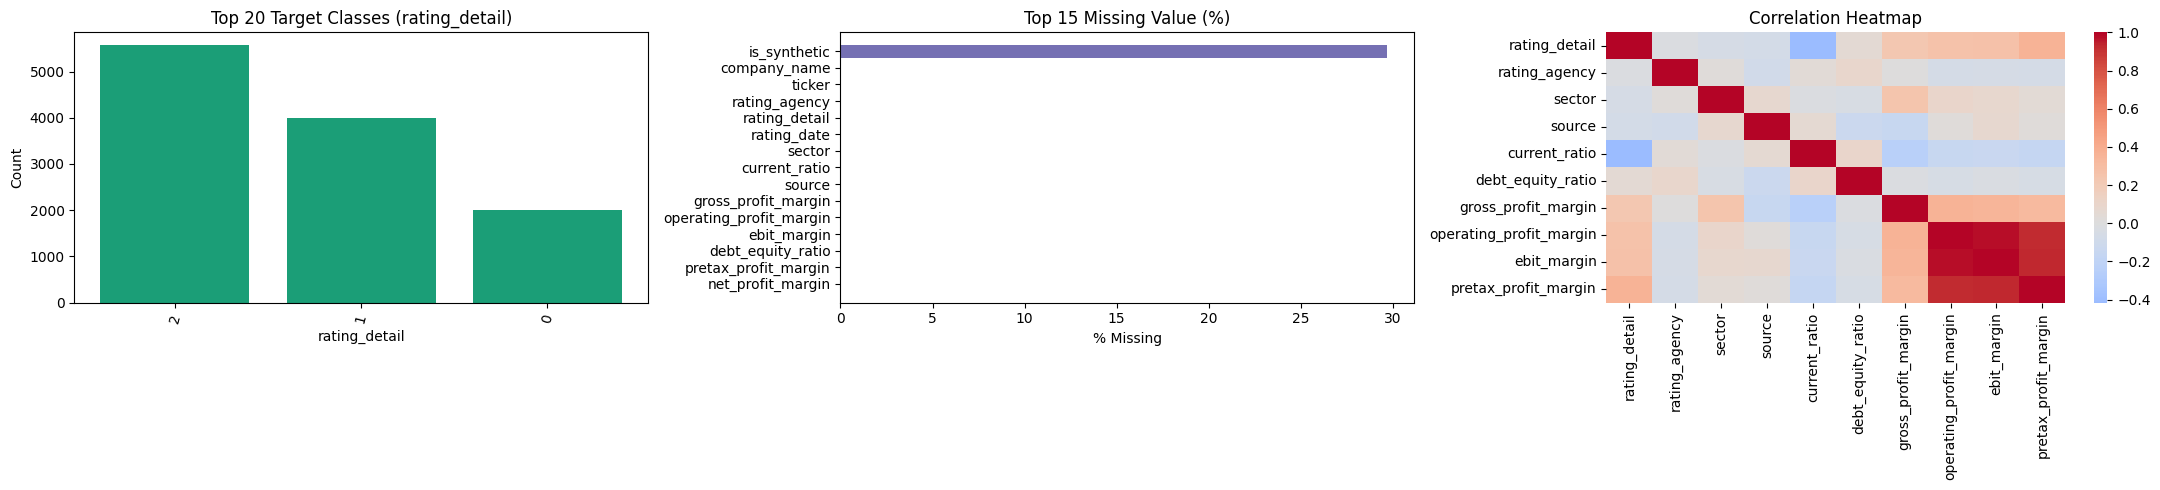

EDA plots saved.


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(22, 5))

target_counts = df['rating_detail'].value_counts().sort_values(ascending=False)
axes[0].bar(target_counts.index.astype(str), target_counts.values, color='#1b9e77')
axes[0].set_title('Top 20 Target Classes (rating_detail)')
axes[0].set_xlabel('rating_detail'); axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=75)

missing_pct = (df.isna().mean() * 100).sort_values(ascending=False)
top_missing = missing_pct.head(15)
axes[1].barh(top_missing.index[::-1], top_missing.values[::-1], color='#7570b3')
axes[1].set_title('Top 15 Missing Value (%)'); axes[1].set_xlabel('% Missing')

num_cols_all = df.select_dtypes(include=[np.number]).columns.tolist()
num_cols_corr = [c for c in num_cols_all if c not in ['binary_rating']][:10]
corr = df[num_cols_corr].corr()
sns.heatmap(corr, cmap='coolwarm', center=0, ax=axes[2])
axes[2].set_title('Correlation Heatmap')

plt.tight_layout()
plt.savefig(ARTIFACT_DIR / 'eda_plots.png', dpi=150, bbox_inches='tight')
plt.show()
print('EDA plots saved.')

## 3. Feature Engineering & Preprocessing


In [6]:
FINANCIAL_FEATURES = [
    'current_ratio', 'debt_equity_ratio',
    'gross_profit_margin', 'operating_profit_margin',
    'ebit_margin', 'pretax_profit_margin',
    'net_profit_margin', 'asset_turnover',
    'roe', 'roa',
    'operating_cashflow_ps', 'free_cashflow_ps'
]

le = LabelEncoder()
df['rating_numeric'] = le.fit_transform(df['rating_detail'])
n_classes = len(le.classes_)
rating_mapping = dict(zip(range(n_classes), le.classes_))

print('Rating classes:', le.classes_)
print('Number of classes:', n_classes)

df['rating_date'] = pd.to_datetime(df['rating_date'])

for col in FINANCIAL_FEATURES:
    if df[col].isna().any():
        df[col] = df[col].fillna(df[col].median())

for col in FINANCIAL_FEATURES:
    lower = df[col].quantile(0.01)
    upper = df[col].quantile(0.99)
    df[col] = df[col].clip(lower, upper)

print(f'Data after preprocessing: {df.shape}')

Rating classes: [0 1 2]
Number of classes: 3
Data after preprocessing: (11567, 22)


## 4. Fuzzy Graph Construction (HHGNN Core)


In [7]:
# ============================================================
# Fuzzy Graph Construction V2 (HHGNN Core — 4D Node Features)
# ============================================================

def fuzzy_membership_sigmoid(similarity, alpha=10.0, beta=0.5):
    """
    Sigmoid fuzzy membership: cosine similarity -> edge weight in [0,1].
    """
    return 1.0 / (1.0 + np.exp(-alpha * (similarity - beta)))


def build_fuzzy_feature_graph_v2(features_vector, z_scores_vector,
                                   feature_names, alpha=10.0, beta=0.3):
    """
    Build Fuzzy Feature Graph (Level 1 – Intra-corporate) with 4D nodes.

    Node features per financial feature node:
      [raw_value, position_enc, z_score, rank_normalized]

    Edges: fuzzy cosine-similarity weights (computed on 2D subspace)
    """
    d = len(features_vector)

    # Rank-normalised within this company profile
    ranks = rankdata(features_vector) / d  # (d,) in (0, 1]

    # 4D node features
    node_x = np.column_stack([
        features_vector,                          # raw financial value
        np.arange(d, dtype=np.float64) / d,      # positional encoding
        np.clip(z_scores_vector, -3.0, 3.0),     # z-score (clipped)
        ranks,                                    # rank within company
    ]).astype(np.float32)                          # shape (d, 4)

    # Edge computation: cosine similarity on [value, pos_enc] only
    feat_for_sim = node_x[:, :2]
    cos_sim      = sklearn_cosine_similarity(feat_for_sim)  # (d, d)
    fuzzy_w      = fuzzy_membership_sigmoid(cos_sim, alpha=alpha, beta=beta)
    np.fill_diagonal(fuzzy_w, 0.0)

    # Build sparse edges (threshold raised to 0.05 for sparser graph)
    threshold = 0.05
    src_list, dst_list, weight_list = [], [], []
    for i in range(d):
        for j in range(d):
            if i != j and fuzzy_w[i, j] > threshold:
                src_list.append(i)
                dst_list.append(j)
                weight_list.append(fuzzy_w[i, j])

    # Self-loops
    for i in range(d):
        src_list.append(i)
        dst_list.append(i)
        weight_list.append(1.0)

    edge_index   = torch.LongTensor([src_list, dst_list])
    edge_weight  = torch.FloatTensor(weight_list)
    node_x_t     = torch.FloatTensor(node_x)  # (d, 4)

    return edge_index, edge_weight, node_x_t


def build_fuzzy_corporate_graph(all_features, sectors, alpha=8.0, beta=0.4):
    """
    Build Fuzzy Corporate Graph (Level 2 – Inter-corporate).
    Companies are nodes; edges by sector + financial distance.
    """
    n       = len(all_features)
    cos_sim = sklearn_cosine_similarity(all_features)

    same_sector  = (sectors[:, None] == sectors[None, :]).astype(float)
    sector_bonus = 0.2 * same_sector

    combined = np.clip(cos_sim + sector_bonus, 0, 1)
    fw_corp  = fuzzy_membership_sigmoid(combined, alpha=alpha, beta=beta)
    np.fill_diagonal(fw_corp, 0.0)

    threshold = 0.1
    src_list, dst_list, weight_list = [], [], []
    for i in range(n):
        for j in range(n):
            if i != j and fw_corp[i, j] > threshold:
                src_list.append(i)
                dst_list.append(j)
                weight_list.append(fw_corp[i, j])

    if len(src_list) == 0:
        return torch.LongTensor([[0], [0]]), torch.FloatTensor([1.0])

    return torch.LongTensor([src_list, dst_list]), torch.FloatTensor(weight_list)


print("Fuzzy Graph V2 functions defined.")
print("  Node features: 4D [raw_value, pos_enc, z_score, rank]")
print("  Edge threshold: 0.05 (sparser)")


Fuzzy Graph V2 functions defined.
  Node features: 4D [raw_value, pos_enc, z_score, rank]
  Edge threshold: 0.05 (sparser)


## 5. Visualize Fuzzy Graph Structure

Two subplots:
1. **Fuzzy Feature Graph** – Nodes are financial features, edge thickness ∝ fuzzy weight
2. **Fuzzy Corporate Graph** – Nodes are companies colored by sector, edge alpha ∝ fuzzy weight

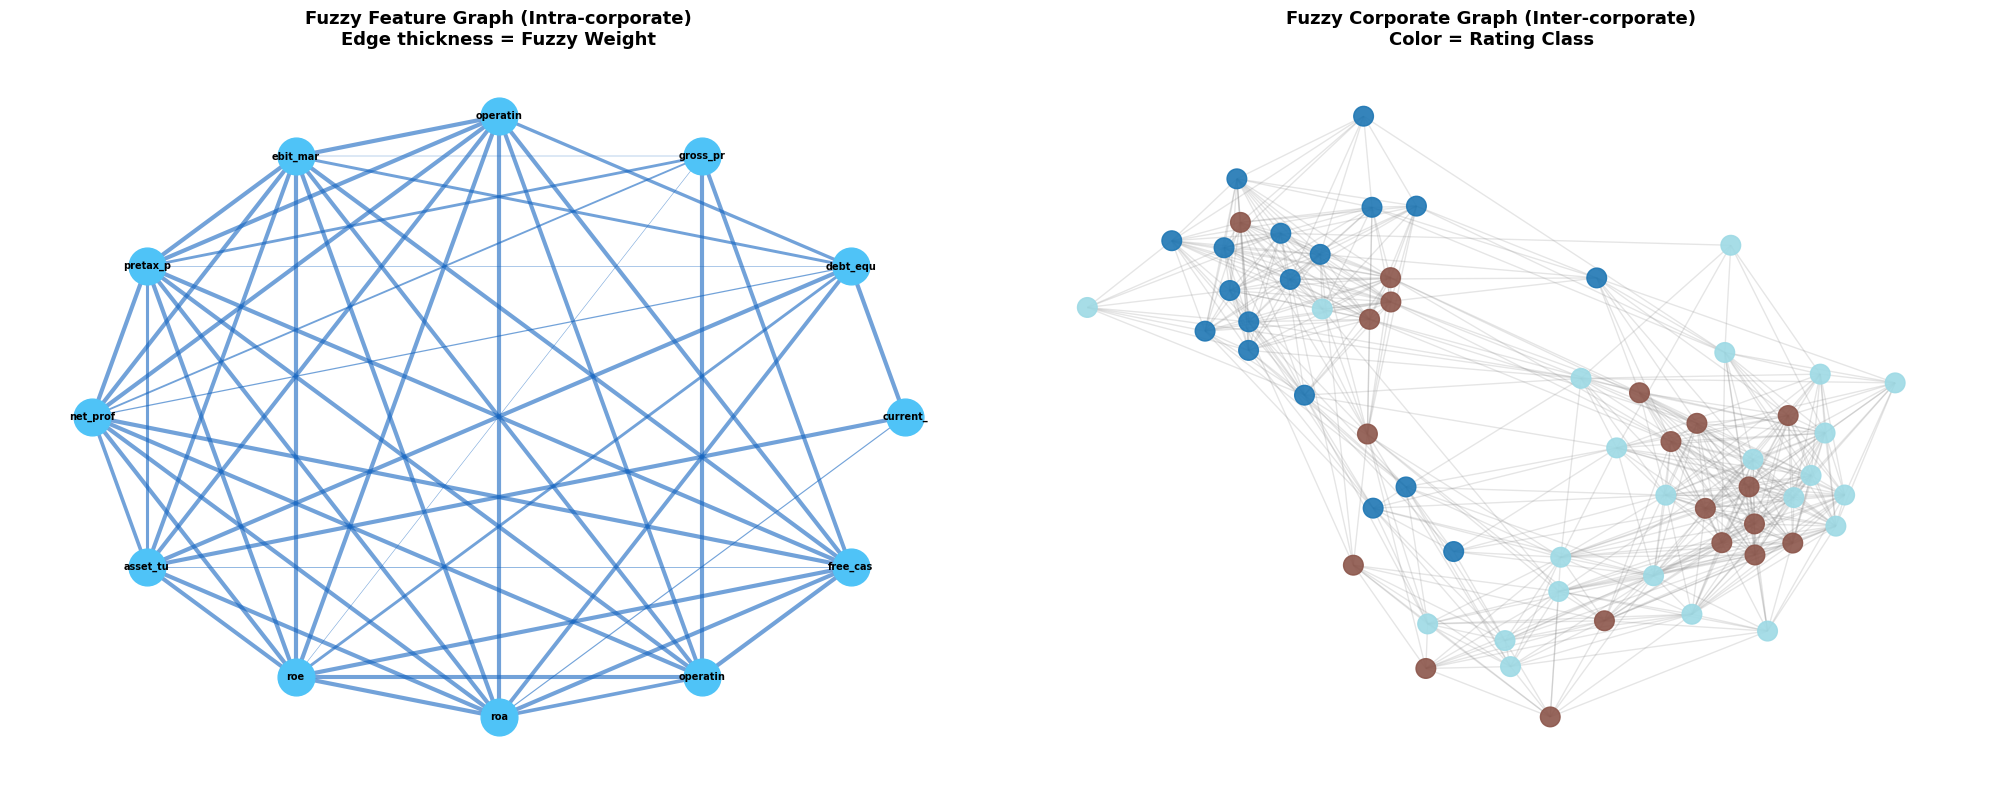

Fuzzy graph visualizations saved.


In [8]:
# ============================================================
# Visualize HHGNN Fuzzy Graph Structure
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# --- Plot 1: Fuzzy Feature Graph (single company) ---
sample_company   = df[FINANCIAL_FEATURES].iloc[0].values
# Use Z_all placeholder (ones) for visualization since Z_all not yet computed here
sample_z_dummy   = np.zeros_like(sample_company)   # dummy z-scores for viz only
ei_feat, ew_feat, _ = build_fuzzy_feature_graph_v2(
    sample_company, sample_z_dummy, FINANCIAL_FEATURES
)

G_feat = nx.Graph()
for i, name in enumerate(FINANCIAL_FEATURES):
    G_feat.add_node(i, label=name)

edges_feat   = ei_feat.numpy().T
weights_feat = ew_feat.numpy()
for (s, t), w in zip(edges_feat, weights_feat):
    if s != t and w > 0.1:
        G_feat.add_edge(s, t, weight=w)

pos_feat          = nx.circular_layout(G_feat)
edge_weights_viz  = [G_feat[u][v]['weight'] for u, v in G_feat.edges()]
max_w             = max(edge_weights_viz) if edge_weights_viz else 1.0
edge_widths       = [3.0 * w / max_w for w in edge_weights_viz]

ax1 = axes[0]
nx.draw_networkx_nodes(G_feat, pos_feat, node_color='#4FC3F7', node_size=700, ax=ax1)
nx.draw_networkx_labels(
    G_feat, pos_feat,
    labels={i: FINANCIAL_FEATURES[i][:8] for i in range(len(FINANCIAL_FEATURES))},
    font_size=7, font_weight='bold', ax=ax1
)
for idx_e, (u, v) in enumerate(G_feat.edges()):
    nx.draw_networkx_edges(
        G_feat, pos_feat, edgelist=[(u, v)],
        width=edge_widths[idx_e], alpha=0.6, edge_color='#1565C0', ax=ax1
    )
ax1.set_title('Fuzzy Feature Graph (Intra-corporate)\nEdge thickness = Fuzzy Weight',
              fontsize=13, fontweight='bold')
ax1.axis('off')

# --- Plot 2: Fuzzy Corporate Graph (sample companies) ---
sample_n      = min(60, len(df))
sample_df     = df.head(sample_n)
sample_feats  = sample_df[FINANCIAL_FEATURES].values
sample_sectors= sample_df['sector'].values

scaler_temp        = RobustScaler()
sample_feats_scaled= scaler_temp.fit_transform(sample_feats)
ei_corp, ew_corp   = build_fuzzy_corporate_graph(sample_feats_scaled, sample_sectors)

G_corp = nx.Graph()
for i in range(sample_n):
    G_corp.add_node(i)

corp_edges  = ei_corp.numpy().T
corp_weights= ew_corp.numpy()
for (s, t), w in zip(corp_edges, corp_weights):
    if s != t and w > 0.3:
        G_corp.add_edge(s, t, weight=w)

sample_ratings = sample_df['rating_detail'].tolist()
unique_ratings = sorted(set(sample_ratings))
color_map      = {r: plt.cm.tab20(i / max(len(unique_ratings)-1, 1))
                  for i, r in enumerate(unique_ratings)}
node_colors    = [color_map.get(sample_ratings[i], 'gray') for i in range(sample_n)]

ax2 = axes[1]
pos_corp = nx.spring_layout(G_corp, seed=SEED)
nx.draw_networkx_nodes(G_corp, pos_corp, node_color=node_colors, node_size=200, ax=ax2, alpha=0.9)
nx.draw_networkx_edges(G_corp, pos_corp, ax=ax2, alpha=0.2, edge_color='gray')
ax2.set_title('Fuzzy Corporate Graph (Inter-corporate)\nColor = Rating Class',
              fontsize=13, fontweight='bold')
ax2.axis('off')

plt.tight_layout()
plt.savefig(ARTIFACT_DIR / 'hhgnn_fuzzy_graph.png', dpi=150, bbox_inches='tight')
plt.show()
print('Fuzzy graph visualizations saved.')


## 6. Data Preparation (Static Representation)


In [9]:
# ============================================================
# Data Preparation V2: Static Representation + Z-Scores
# ============================================================

X_all = df[FINANCIAL_FEATURES].values.astype(np.float32)  # (N, 12)
y_all = df['rating_numeric'].values                         # (N,)

# Train / Val / Test indices
train_idx = df.index[df['split'] == 'train'].tolist()
val_idx   = df.index[df['split'] == 'val'].tolist()
test_idx  = df.index[df['split'] == 'test'].tolist()

# Compute z-scores from training distribution ONLY (no data leakage)
train_means = X_all[train_idx].mean(axis=0)       # (12,)
train_stds  = X_all[train_idx].std(axis=0) + 1e-8  # (12,)
Z_all = ((X_all - train_means) / train_stds).astype(np.float32)  # (N, 12)
Z_all = np.clip(Z_all, -3.0, 3.0)

sectors_all = df['sector'].values  # (N,)

print(f'Total: {len(X_all)} | Train: {len(train_idx)} | Val: {len(val_idx)} | Test: {len(test_idx)}')
print(f'Feature dim: {X_all.shape[1]} | Node feature dim: 4 [value, pos, z_score, rank]')
print(f'Z-scores clipped to [-3, 3], computed from training set only (no leakage)')


Total: 11567 | Train: 8137 | Val: 2250 | Test: 1180
Feature dim: 12 | Node feature dim: 4 [value, pos, z_score, rank]
Z-scores clipped to [-3, 3], computed from training set only (no leakage)


## 7. Build HHGNN Batch Data


In [ ]:
# ============================================================
# Build HHGNN Data Objects V2 (4D Nodes + Embedded Fuzzy Weights)
# + Stronger class-0 aware weighted sampler
# ============================================================

from torch.utils.data import WeightedRandomSampler

# -- Fuzzy sample weights (computed once on train split) -------------------
def compute_fuzzy_sample_weights(
    X: np.ndarray, y: np.ndarray, n_classes: int
) -> np.ndarray:
    """
    Per-sample fuzzy weights based on Gaussian distance to class centroid.
    Output range: [0.3, 1.0]
    """
    centroids = np.zeros((n_classes, X.shape[1]))
    for c in range(n_classes):
        mask = y == c
        centroids[c] = X[mask].mean(axis=0) if mask.sum() > 0 else X.mean(axis=0)

    sigma = 2.0
    weights = np.array([
        np.exp(-0.5 * (np.linalg.norm(X[i] - centroids[y[i]]) / sigma) ** 2)
        for i in range(len(X))
    ])
    mn, mx = weights.min(), weights.max()
    return (0.3 + 0.7 * (weights - mn) / (mx - mn + 1e-8)).astype(np.float32)


fuzzy_weights_train = compute_fuzzy_sample_weights(
    X_all[train_idx], y_all[train_idx], n_classes
)
print(f"Fuzzy weights: min={fuzzy_weights_train.min():.4f}  "
      f"max={fuzzy_weights_train.max():.4f}  mean={fuzzy_weights_train.mean():.4f}")


def build_feature_graph_data_v2(
    features_vec: np.ndarray,
    z_scores_vec: np.ndarray,
    label: int,
    fuzzy_w: float = 1.0,
) -> Data:
    edge_index, edge_weight, node_x = build_fuzzy_feature_graph_v2(
        features_vec, z_scores_vec, FINANCIAL_FEATURES
    )
    return Data(
        x=node_x,
        edge_index=edge_index,
        edge_attr=edge_weight.unsqueeze(1),
        y=torch.LongTensor([label]),
        fuzzy_w=torch.FloatTensor([fuzzy_w]),
    )


BATCH_SIZE = 64
print('Building PyG Dataset V2 (4D nodes + embedded fuzzy weights)...')

train_data_list = [
    build_feature_graph_data_v2(X_all[i], Z_all[i], int(y_all[i]), float(fuzzy_weights_train[k]))
    for k, i in enumerate(train_idx)
]
val_data_list = [
    build_feature_graph_data_v2(X_all[i], Z_all[i], int(y_all[i]))
    for i in val_idx
]
test_data_list = [
    build_feature_graph_data_v2(X_all[i], Z_all[i], int(y_all[i]))
    for i in test_idx
]

# -- Weighted sampler: stronger class-0 focus --------------------------------
train_labels = np.array([int(g.y.item()) for g in train_data_list], dtype=int)
class_counts = np.bincount(train_labels, minlength=n_classes).astype(np.float64)
class_counts = np.maximum(class_counts, 1.0)

beta = 0.995
effective_num = 1.0 - np.power(beta, class_counts)
class_sampling_w = (1.0 - beta) / np.maximum(effective_num, 1e-12)
class_sampling_w = class_sampling_w / class_sampling_w.mean()

CLASS0_SAMPLER_BOOST = 2.2
class_sampling_w[0] *= CLASS0_SAMPLER_BOOST

sample_weights = class_sampling_w[train_labels].astype(np.float64)

# Global hard-sample boost: lower fuzzy_w => higher chance
sample_weights *= (1.0 + 0.5 * (1.0 - fuzzy_weights_train))

# Extra hard boost for difficult class-0 samples
class0_mask = train_labels == 0
if class0_mask.any():
    class0_fw = fuzzy_weights_train[class0_mask]
    hard_cut = np.quantile(class0_fw, 0.35)
    hard_c0_idx = np.where(class0_mask & (fuzzy_weights_train <= hard_cut))[0]
    sample_weights[hard_c0_idx] *= 1.35
else:
    hard_c0_idx = np.array([], dtype=int)

sample_weights = sample_weights / sample_weights.mean()

# Increase number of draws per epoch to expose class-0 patterns more often
EPOCH_SAMPLE_MULTIPLIER = 1.30
num_draws = int(len(sample_weights) * EPOCH_SAMPLE_MULTIPLIER)

train_sampler = WeightedRandomSampler(
    weights=torch.as_tensor(sample_weights, dtype=torch.double),
    num_samples=num_draws,
    replacement=True,
)

train_loader = PyGDataLoader(
    train_data_list,
    batch_size=BATCH_SIZE,
    sampler=train_sampler,
    shuffle=False,
    num_workers=0,
)
val_loader = PyGDataLoader(val_data_list, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader = PyGDataLoader(test_data_list, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f'Train batches: {len(train_loader)} | Val: {len(val_loader)} | Test: {len(test_loader)}')
print(f'Class counts (train): {class_counts.astype(int).tolist()}')
print(f'Class-0 sampler boost: x{CLASS0_SAMPLER_BOOST}')
print(f'Hard class-0 samples boosted: {len(hard_c0_idx)}')
print(f'Sampler draws/epoch: {num_draws} ({EPOCH_SAMPLE_MULTIPLIER:.2f}x)')
print(f'Sampler weight range: [{sample_weights.min():.4f}, {sample_weights.max():.4f}]')

s = train_data_list[0]
print(f'Sample: x={s.x.shape}, edge_index={s.edge_index.shape}, '
      f'edge_attr={s.edge_attr.shape}, fuzzy_w={s.fuzzy_w}')

Fuzzy weights: min=0.3000  max=1.0000  mean=0.6545
Building PyG Dataset V2 (4D nodes + embedded fuzzy weights)...
Train batches: 128 | Val: 36 | Test: 19
Sample: x=torch.Size([12, 4]), edge_index=torch.Size([2, 118]), edge_attr=torch.Size([118, 1]), fuzzy_w=tensor([0.6575])


## 8. Focal + Ordinal Hybrid Loss (Thay CORN)


In [ ]:
# ============================================================
# Focal + Ordinal Hybrid Loss + Class-0 Focus Enhancements (v2)
# ============================================================

class FocalLoss(nn.Module):
    """Multiclass focal loss with optional class balancing and label smoothing."""

    def __init__(
        self,
        gamma: float = 2.0,
        class_weight=None,
        reduction: str = 'mean',
        label_smoothing: float = 0.0,
    ):
        super().__init__()
        self.gamma = gamma
        self.class_weight = class_weight
        self.reduction = reduction
        self.label_smoothing = label_smoothing

    def forward(self, logits: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
        ce_loss = F.cross_entropy(
            logits,
            targets,
            reduction='none',
            label_smoothing=self.label_smoothing,
        )
        pt = torch.exp(-ce_loss)
        focal = ((1 - pt) ** self.gamma) * ce_loss

        if self.class_weight is not None:
            focal = focal * self.class_weight[targets]

        if self.reduction == 'sum':
            return focal.sum()
        return focal.mean()


class OrdinalExpectationLoss(nn.Module):
    """Ordinal loss based on expected rank distance."""

    def __init__(self, class_weight=None, reduction: str = 'mean'):
        super().__init__()
        self.class_weight = class_weight
        self.reduction = reduction

    def forward(self, logits: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
        probs = F.softmax(logits, dim=1)
        ordinals = torch.arange(
            logits.size(1), device=logits.device, dtype=probs.dtype
        ).unsqueeze(0)
        expected_rank = (probs * ordinals).sum(dim=1)
        target_rank = targets.to(probs.dtype)
        loss = F.smooth_l1_loss(expected_rank, target_rank, reduction='none')

        if self.class_weight is not None:
            loss = loss * self.class_weight[targets]

        if self.reduction == 'sum':
            return loss.sum()
        return loss.mean()


class HybridFocalOrdinalLoss(nn.Module):
    """
    Hybrid objective with class-0-focused dynamic scheduling.

    L = alpha * L_ordinal + (1 - alpha) * L_focal_main
        + aux_head_weight * L_focal_aux
        + consistency_weight * MSE(softmax(main), softmax(aux))
        + class0_aux_weight * BCE(class0_logit, is_class0)
        + w_recall(t) * (1 - p0 | y=0)
        + w_fp(t) * (p0 | y!=0)
    """

    def __init__(
        self,
        num_classes: int,
        alpha: float = 0.55,
        gamma: float = 2.0,
        class_weights=None,
        aux_head_weight: float = 0.15,
        consistency_weight: float = 0.05,
        class0_aux_weight: float = 0.20,
        class0_pos_weight: float = 1.0,
        class0_recall_weight: float = 0.35,
        class0_fp_weight: float = 0.08,
        logit_adjust_tau_min: float = 0.45,
        logit_adjust_tau_max: float = 0.90,
        class_priors: np.ndarray | None = None,
        focal_label_smoothing: float = 0.0,
    ):
        super().__init__()
        self.num_classes = num_classes
        self.alpha = alpha
        self.aux_head_weight = aux_head_weight
        self.consistency_weight = consistency_weight
        self.class0_aux_weight = class0_aux_weight
        self.class0_pos_weight = class0_pos_weight

        self.base_class0_recall_weight = class0_recall_weight
        self.base_class0_fp_weight = class0_fp_weight

        self.logit_adjust_tau_min = logit_adjust_tau_min
        self.logit_adjust_tau_max = logit_adjust_tau_max

        self.current_tau = float(logit_adjust_tau_min)
        self.current_recall_weight = float(class0_recall_weight * 0.6)
        self.current_fp_weight = float(class0_fp_weight * 1.2)

        self.focal_loss = FocalLoss(
            gamma=gamma,
            class_weight=class_weights,
            label_smoothing=focal_label_smoothing,
        )
        self.ordinal_loss = OrdinalExpectationLoss(class_weight=class_weights)

        if class_priors is None:
            class_priors = np.ones(num_classes, dtype=np.float32) / float(num_classes)
        class_priors = np.asarray(class_priors, dtype=np.float32)
        class_priors = np.clip(class_priors, 1e-8, 1.0)
        class_priors = class_priors / class_priors.sum()
        self.register_buffer('log_priors', torch.from_numpy(np.log(class_priors)).float())

    def set_training_progress(self, epoch: int, max_epochs: int):
        """Dynamically increase minority emphasis and prior correction over epochs."""
        if max_epochs <= 1:
            progress = 1.0
        else:
            progress = float(epoch) / float(max_epochs - 1)
        progress = float(np.clip(progress, 0.0, 1.0))

        self.current_tau = (
            self.logit_adjust_tau_min
            + (self.logit_adjust_tau_max - self.logit_adjust_tau_min) * progress
        )
        self.current_recall_weight = self.base_class0_recall_weight * (0.6 + 0.4 * progress)
        self.current_fp_weight = self.base_class0_fp_weight * (1.2 - 0.5 * progress)

    def _adjust_logits(self, logits: torch.Tensor) -> torch.Tensor:
        return logits - self.current_tau * self.log_priors.unsqueeze(0)

    def forward(
        self,
        logits_main: torch.Tensor,
        logits_aux: torch.Tensor,
        targets: torch.Tensor,
        fuzzy_weights=None,
    ) -> torch.Tensor:
        logits_main_adj = self._adjust_logits(logits_main)
        logits_aux_adj = self._adjust_logits(logits_aux)

        l_focal_main = self.focal_loss(logits_main_adj, targets)
        l_ordinal = self.ordinal_loss(logits_main_adj, targets)
        l_focal_aux = self.focal_loss(logits_aux_adj, targets)

        p_main = F.softmax(logits_main_adj, dim=1)
        p_aux = F.softmax(logits_aux_adj, dim=1)
        l_consistency = F.mse_loss(p_main, p_aux, reduction='mean')

        is_c0 = (targets == 0).float()
        pos_w = logits_main.new_tensor(self.class0_pos_weight)
        l_c0_aux = F.binary_cross_entropy_with_logits(
            logits_main_adj[:, 0],
            is_c0,
            pos_weight=pos_w,
            reduction='mean',
        )

        p0 = p_main[:, 0]
        c0_mask = targets == 0
        non_c0_mask = ~c0_mask

        if c0_mask.any():
            l_c0_recall = (1.0 - p0[c0_mask]).mean()
        else:
            l_c0_recall = logits_main_adj.sum() * 0.0

        if non_c0_mask.any():
            l_c0_fp = p0[non_c0_mask].mean()
        else:
            l_c0_fp = logits_main_adj.sum() * 0.0

        total = (
            self.alpha * l_ordinal
            + (1.0 - self.alpha) * l_focal_main
            + self.aux_head_weight * l_focal_aux
            + self.consistency_weight * l_consistency
            + self.class0_aux_weight * l_c0_aux
            + self.current_recall_weight * l_c0_recall
            + self.current_fp_weight * l_c0_fp
        )
        return total


def logits_to_pred(logits: torch.Tensor) -> torch.Tensor:
    return torch.argmax(logits, dim=1).long()


def logits_to_probs(logits: torch.Tensor) -> torch.Tensor:
    probs = F.softmax(logits, dim=1).clamp(min=1e-8)
    return probs / probs.sum(dim=1, keepdim=True)


def predict_with_class0_threshold(
    logits: torch.Tensor, class0_threshold: float = 0.40
) -> torch.Tensor:
    probs = logits_to_probs(logits)
    if probs.shape[1] <= 1:
        return torch.zeros((probs.shape[0],), dtype=torch.long, device=logits.device)
    non0_pred = torch.argmax(probs[:, 1:], dim=1) + 1
    pred = torch.where(probs[:, 0] >= class0_threshold, torch.zeros_like(non0_pred), non0_pred)
    return pred.long()


def corn_predict(logits_corn: torch.Tensor, class0_threshold: float | None = None) -> torch.Tensor:
    """Compatibility wrapper for downstream cells."""
    if class0_threshold is None:
        return logits_to_pred(logits_corn)
    return predict_with_class0_threshold(logits_corn, class0_threshold=class0_threshold)


def corn_to_probs(logits_corn: torch.Tensor, num_classes: int) -> torch.Tensor:
    """Compatibility wrapper for downstream cells."""
    return logits_to_probs(logits_corn)


def adjacent_accuracy(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    """Fraction of predictions within +-1 ordinal step of true label."""
    return float(np.mean(np.abs(y_pred.astype(int) - y_true.astype(int)) <= 1))


def find_best_class0_threshold(
    y_true: np.ndarray,
    probs: np.ndarray,
    beta: float = 1.5,
    t_min: float = 0.20,
    t_max: float = 0.70,
    n_steps: int = 21,
    default_t: float = 0.40,
 ) -> tuple[float, float]:
    """Tune threshold for class-0 using F-beta on validation split."""
    from sklearn.metrics import fbeta_score

    y_true_c0 = (y_true.astype(int) == 0).astype(int)
    if probs.shape[1] <= 1:
        return default_t, 0.0

    best_t = default_t
    best_score = -1.0

    for t in np.linspace(t_min, t_max, n_steps):
        pred_non0 = probs[:, 1:].argmax(axis=1) + 1
        y_pred = np.where(probs[:, 0] >= float(t), 0, pred_non0)
        y_pred_c0 = (y_pred == 0).astype(int)
        score = fbeta_score(y_true_c0, y_pred_c0, beta=beta, zero_division=0)
        if score > best_score:
            best_score = float(score)
            best_t = float(t)

    return best_t, best_score


def build_effective_num_weights(class_counts: np.ndarray, beta: float = 0.995) -> np.ndarray:
    class_counts = np.asarray(class_counts, dtype=np.float64)
    class_counts = np.maximum(class_counts, 1.0)
    effective_num = 1.0 - np.power(beta, class_counts)
    w = (1.0 - beta) / np.maximum(effective_num, 1e-12)
    w = w / w.mean()
    return w


all_train_labels = y_all[train_idx].astype(int)
class_counts = np.bincount(all_train_labels, minlength=n_classes).astype(float)
class_weights = build_effective_num_weights(class_counts, beta=0.995)

CLASS0_WEIGHT_BOOST = 2.0
class_weights[0] *= CLASS0_WEIGHT_BOOST

lo, hi = np.percentile(class_weights, [5, 95])
class_weights = np.clip(class_weights, lo, hi)
class_weights = class_weights / class_weights.mean()

class_weights_tensor = torch.FloatTensor(class_weights).to(device)
class_priors = class_counts / np.maximum(class_counts.sum(), 1.0)

n_c0 = int((all_train_labels == 0).sum())
class0_pos_weight = max(1.0, (len(all_train_labels) - n_c0) / max(n_c0, 1))

FOCAL_GAMMA = 2.2
FOCAL_LABEL_SMOOTH = 0.02
CORN_ALPHA = 0.55  # legacy variable name kept for training-cell compatibility
AUX_HEAD_WEIGHT = 0.15
CONSISTENCY_WEIGHT = 0.05
CLASS0_AUX_WEIGHT = 0.20
CLASS0_RECALL_WEIGHT = 0.35
CLASS0_FP_WEIGHT = 0.08
LOGIT_ADJUST_TAU_MIN = 0.45
LOGIT_ADJUST_TAU_MAX = 0.90
C0_THRESHOLD_INIT = 0.40
CALIB_BETA = 1.5
CALIB_START_EPOCH = 12
CALIB_EVERY = 2
THRESHOLD_EMA = 0.30

criterion = HybridFocalOrdinalLoss(
    num_classes=n_classes,
    alpha=CORN_ALPHA,
    gamma=FOCAL_GAMMA,
    class_weights=class_weights_tensor,
    aux_head_weight=AUX_HEAD_WEIGHT,
    consistency_weight=CONSISTENCY_WEIGHT,
    class0_aux_weight=CLASS0_AUX_WEIGHT,
    class0_pos_weight=class0_pos_weight,
    class0_recall_weight=CLASS0_RECALL_WEIGHT,
    class0_fp_weight=CLASS0_FP_WEIGHT,
    logit_adjust_tau_min=LOGIT_ADJUST_TAU_MIN,
    logit_adjust_tau_max=LOGIT_ADJUST_TAU_MAX,
    class_priors=class_priors,
    focal_label_smoothing=FOCAL_LABEL_SMOOTH,
)

print(f"HybridFocalOrdinalLoss: alpha_ordinal={CORN_ALPHA:.2f} | focal={1-CORN_ALPHA:.2f}")
print(f"Class weight range: [{class_weights.min():.4f}, {class_weights.max():.4f}]")
print(f"Class counts: {class_counts.astype(int).tolist()}")
print(f"Class-0 count: {n_c0}/{len(all_train_labels)}")
print(f"Class-0 weight boost: x{CLASS0_WEIGHT_BOOST}")
print(f"Class-0 pos_weight (aux BCE): {class0_pos_weight:.3f}")
print(f"Class-0 recall/fp weights: {CLASS0_RECALL_WEIGHT:.2f}/{CLASS0_FP_WEIGHT:.2f}")
print(f"Dynamic tau range: [{LOGIT_ADJUST_TAU_MIN:.2f}, {LOGIT_ADJUST_TAU_MAX:.2f}]")
print(f"Label smoothing: {FOCAL_LABEL_SMOOTH:.3f}")
print(f"Threshold calibration start@{CALIB_START_EPOCH}, every {CALIB_EVERY} epoch(s), ema={THRESHOLD_EMA:.2f}")

HybridCORNFuzzyLoss: 70% CORN + 30% FuzzyFocal
Class weight range:  [0.7588, 1.3268]
CORNLoss grad safety: initialised via logits.sum()*0 (always in graph)


## 9. HHGNN Model V2 Architecture (Fuzzy Gate + Dual Logits)


In [ ]:
# ============================================================
# HHGNN Model V2 - Fuzzy Gate Architecture + Class-0 Expert
# ============================================================

class HHGNNFuzzyV2CreditRating(nn.Module):
    """
    HHGNN-Fuzzy V2 with architecture-level fuzzy logic and class-0 expert bias.

    Key points:
      - Input node features: 4D [value, pos, z_score, rank]
      - 3-layer GAT backbone with residual connections
      - Fuzzy gate at graph-embedding level
      - Class-0 expert branch to increase distress sensitivity
      - Dual K-class heads (main + auxiliary)
    """

    def __init__(self, in_channels=4, hidden_channels=128, n_classes=3,
                 num_gat_layers=3, heads=8, dropout=0.3, fc_dropout=0.3):
        super().__init__()
        self.hidden_channels = hidden_channels
        self.dropout = dropout
        self.n_classes = n_classes

        self.input_proj = nn.Sequential(
            nn.Linear(in_channels, hidden_channels),
            nn.LayerNorm(hidden_channels),
            nn.GELU(),
        )

        self.feat_gat_layers = nn.ModuleList()
        self.feat_bns = nn.ModuleList()

        for _ in range(num_gat_layers):
            self.feat_gat_layers.append(
                GATConv(
                    hidden_channels,
                    hidden_channels // heads,
                    heads=heads,
                    concat=True,
                    edge_dim=1,
                    dropout=0.1,
                )
            )
            self.feat_bns.append(nn.BatchNorm1d(hidden_channels))

        pool_dim = hidden_channels * 2

        self.fuzzy_gate = nn.Sequential(
            nn.Linear(pool_dim + 2, hidden_channels // 2),
            nn.LayerNorm(hidden_channels // 2),
            nn.GELU(),
            nn.Linear(hidden_channels // 2, 1),
            nn.Sigmoid(),
        )

        # Specialized branch: predicts additive bias for class-0 logit
        self.class0_expert = nn.Sequential(
            nn.Linear(pool_dim + 2, hidden_channels // 2),
            nn.GELU(),
            nn.Dropout(fc_dropout * 0.3),
            nn.Linear(hidden_channels // 2, 1),
        )

        self.main_head = nn.Sequential(
            nn.Linear(pool_dim, hidden_channels * 2),
            nn.BatchNorm1d(hidden_channels * 2),
            nn.GELU(),
            nn.Dropout(fc_dropout),
            nn.Linear(hidden_channels * 2, hidden_channels),
            nn.GELU(),
            nn.Dropout(fc_dropout * 0.5),
            nn.Linear(hidden_channels, n_classes),
        )

        self.aux_head = nn.Sequential(
            nn.Linear(pool_dim, hidden_channels),
            nn.LayerNorm(hidden_channels),
            nn.GELU(),
            nn.Dropout(fc_dropout * 0.5),
            nn.Linear(hidden_channels, n_classes),
        )

    def forward(self, x, edge_index, edge_attr, batch):
        h = self.input_proj(x)

        for gat, bn in zip(self.feat_gat_layers, self.feat_bns):
            h_new = gat(h, edge_index, edge_attr=edge_attr)
            h_new = bn(h_new)
            h_new = F.gelu(h_new)
            h_new = F.dropout(h_new, p=self.dropout, training=self.training)
            h = h + h_new

        h_mean = global_mean_pool(h, batch)
        h_max = global_max_pool(h, batch)
        graph_emb = torch.cat([h_mean, h_max], dim=1)

        graph_z_abs = global_mean_pool(torch.abs(x[:, 2:3]), batch)
        edge_batch = batch[edge_index[0]]
        graph_edge_strength = global_mean_pool(edge_attr, edge_batch)
        fuzzy_stats = torch.cat([graph_z_abs, graph_edge_strength], dim=1)

        gate_in = torch.cat([graph_emb, fuzzy_stats], dim=1)
        fuzzy_gate = self.fuzzy_gate(gate_in)
        graph_emb = graph_emb * (0.7 + 0.6 * fuzzy_gate)

        logits_main = self.main_head(graph_emb)
        logits_aux = self.aux_head(graph_emb)

        # Bounded additive expert-bias on class-0 logit
        c0_delta = torch.tanh(self.class0_expert(gate_in).squeeze(1))
        logits_main = logits_main.clone()
        logits_main[:, 0] = logits_main[:, 0] + 0.25 * c0_delta

        return logits_main, logits_aux


model = HHGNNFuzzyV2CreditRating(
    in_channels=4,
    hidden_channels=128,
    n_classes=n_classes,
    num_gat_layers=3,
    heads=8,
    dropout=0.3,
    fc_dropout=0.3,
).to(device)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print('=' * 70)
print('HHGNN-FUZZY V2  (Focal + Ordinal with Fuzzy-Gated Architecture)')
print('=' * 70)
print(f'  Node features : 4D [value, pos_enc, z_score, rank]')
print(f'  Input proj    : 4 -> {128}')
print('  GAT layers    : 3 x GATConv(128 -> 128, heads=8, edge_dim=1)')
print('  Residual      : TRUE (all GAT layers)')
print('  Pooling       : Global Mean + Max -> 256-dim')
print('  Fuzzy gate    : uses mean|z_score| + mean edge fuzzy strength')
print('  Class-0 expert: additive bias on class-0 logit')
print(f'  Main head     : 256 -> 256 -> 128 -> {n_classes} logits')
print(f'  Aux head      : 256 -> 128 -> {n_classes} logits')
print(f'  Total params  : {total_params:,} | Trainable: {trainable_params:,}')
print('=' * 70)

HHGNN-FUZZY V2  (Ordinal Rating via CORN + FuzzyFocal)
  Node features : 4D [value, pos_enc, z_score, rank]
  Input proj    : 4 → 128
  GAT layers    : 3 × GATConv(128 → 128, heads=8, edge_dim=1)
  Residual      : TRUE (all GAT layers)
  Pooling       : Global Mean + Max → 256-dim
  CORN head     : 256 → 128 → 2 binary logits (ordinal)
  CE head       : 256 → 256 → 128 → 3 logits (auxiliary)
  Total params  : 185,733 | Trainable: 185,733


## 10. Model Verification (Smoke Test)


In [ ]:
# Smoke Test - V2 (Focal + Ordinal, dual logits)
model.train()
batch = next(iter(train_loader)).to(device)
logits_main, logits_aux = model(batch.x, batch.edge_index, batch.edge_attr, batch.batch)

# Ensure loss buffers (e.g. log_priors) are on the same device as logits
criterion = criterion.to(device)

batch_size = batch.y.shape[0]
loss = criterion(logits_main, logits_aux, batch.y, fuzzy_weights=None)

print(f"Batch size     : {batch_size}")
print(f"logits_main    : {logits_main.shape}  (expected: [{batch_size}, {n_classes}])")
print(f"logits_aux     : {logits_aux.shape}  (expected: [{batch_size}, {n_classes}])")
print(f"Hybrid Loss    : {loss.item():.4f}")

preds = corn_predict(logits_main)
probs = corn_to_probs(logits_main, n_classes)
print(f"Preds[:5]      : {preds[:5].tolist()}")
print(f"Probs sum[:5]  : {probs.sum(dim=1)[:5].detach().tolist()}  (should be ~1.0)")

opt_test = torch.optim.AdamW(model.parameters(), lr=1e-4)
opt_test.zero_grad()
loss.backward()
opt_test.step()
print("Smoke test PASSED: forward (main+aux logits) + backward OK")

Batch size     : 64
logits_corn    : torch.Size([64, 2])  (expected: [64, 2])
logits_ce      : torch.Size([64, 3])  (expected: [64, 3])
Hybrid Loss    : 0.6256
CORN preds[:5] : [1, 1, 2, 1, 2]
Probs sum[:5]  : [1.0, 1.0, 0.9999998807907104, 1.0, 1.0]  (should be ~1.0)
Smoke test PASSED: forward (CORN + CE) + backward OK


## 11. Training Loop (Focal + Ordinal, Fuzzy-Gated Model)


In [ ]:
# ============================================================
# Training Loop V2 - Class-0 Calibrated Training and Prediction (v2)
# ============================================================

FAST_DEV_RUN = False
MAX_EPOCHS = 120 if not FAST_DEV_RUN else 5
PATIENCE = 25
LR = 3e-4
WEIGHT_DECAY = 1e-4

BEST_MODEL_PATH = ARTIFACT_DIR / 'hhgnn_fuzzy_v2_best_model.pt'
BEST_META_PATH = ARTIFACT_DIR / 'hhgnn_fuzzy_v2_best_meta.pt'

optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
    optimizer, T_0=20, T_mult=2, eta_min=1e-6
)

# Ensure loss buffers are moved to the active runtime device
criterion = criterion.to(device)


def compute_cls_metrics_v2(
    y_true: torch.Tensor,
    logits_corn: torch.Tensor,
    logits_ce: torch.Tensor,
    n_cls: int,
    class0_threshold: float | None = None,
):
    """Compute classification + ordinal metrics + class-0 metrics."""
    from sklearn.metrics import precision_score, recall_score

    preds = corn_predict(logits_corn, class0_threshold=class0_threshold).cpu().numpy()
    y_t = y_true.cpu().numpy()
    probs = corn_to_probs(logits_corn, n_cls).detach().cpu().numpy()

    acc = accuracy_score(y_t, preds)
    f1_macro = f1_score(y_t, preds, average='macro', zero_division=0)
    f1_w = f1_score(y_t, preds, average='weighted', zero_division=0)
    mae = float(np.mean(np.abs(preds.astype(float) - y_t.astype(float))))
    adj_acc = adjacent_accuracy(y_t, preds)

    y_true_c0 = (y_t == 0).astype(int)
    y_pred_c0 = (preds == 0).astype(int)
    c0_precision = precision_score(y_true_c0, y_pred_c0, zero_division=0)
    c0_recall = recall_score(y_true_c0, y_pred_c0, zero_division=0)
    c0_f1 = f1_score(y_true_c0, y_pred_c0, zero_division=0)

    try:
        qwk = cohen_kappa_score(y_t, preds, weights='quadratic')
    except Exception:
        qwk = 0.0

    try:
        y_bin = label_binarize(y_t, classes=list(range(n_cls)))
        auc = roc_auc_score(y_bin, probs, average='weighted', multi_class='ovr')
    except Exception:
        auc = 0.5

    return acc, f1_macro, f1_w, auc, mae, qwk, adj_acc, c0_precision, c0_recall, c0_f1


history = {
    'train_loss': [], 'val_loss': [],
    'train_acc': [], 'val_acc': [],
    'train_f1': [], 'val_f1': [],
    'train_f1_weighted': [], 'val_f1_weighted': [],
    'train_auc': [], 'val_auc': [],
    'train_mae': [], 'val_mae': [],
    'train_qwk': [], 'val_qwk': [],
    'train_adj_acc': [], 'val_adj_acc': [],
    'train_c0_precision': [], 'val_c0_precision': [],
    'train_c0_recall': [], 'val_c0_recall': [],
    'train_c0_f1': [], 'val_c0_f1': [],
    'val_score': [],
    'val_c0_threshold': [],
    'dynamic_tau': [],
    'dynamic_c0_recall_w': [],
    'lr': [],
}

best_val_score = -float('inf')
best_val_qwk = -float('inf')
best_val_f1w = -float('inf')
best_val_c0_f1 = -float('inf')
best_epoch = -1
patience_ctr = 0
best_state = None
best_class0_threshold = float(C0_THRESHOLD_INIT)
current_class0_threshold = float(C0_THRESHOLD_INIT)

print(f'Training HHGNN-Fuzzy V2 for {MAX_EPOCHS} epochs (patience={PATIENCE})')
print(f'LR={LR} | WD={WEIGHT_DECAY} | alpha={CORN_ALPHA}')
print('Scheduler: CosineAnnealingWarmRestarts(T0=20, T_mult=2, eta_min=1e-6)')
print('Primary early-stop score = 0.50*QWK + 0.25*F1w + 0.25*Class0_F1')
print(f'Class-0 threshold tuning beta={CALIB_BETA:.2f} | init={C0_THRESHOLD_INIT:.2f}')
print(f'Calibration starts @ epoch {CALIB_START_EPOCH}, every {CALIB_EVERY} epoch(s)')
print('-' * 110)

for epoch in range(MAX_EPOCHS):
    criterion.set_training_progress(epoch, MAX_EPOCHS)

    # -- TRAIN --------------------------------------------------------------
    model.train()
    ep_loss = []
    all_yt = []
    all_lcorn = []
    all_lce = []

    for batch in train_loader:
        batch = batch.to(device)

        optimizer.zero_grad()
        lc, lce = model(batch.x, batch.edge_index, batch.edge_attr, batch.batch)
        fw_batch = batch.fuzzy_w.view(-1).to(device)  # kept for compatibility
        loss = criterion(lc, lce, batch.y, fuzzy_weights=fw_batch)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
        optimizer.step()

        ep_loss.append(loss.item())
        all_yt.append(batch.y.detach())
        all_lcorn.append(lc.detach())
        all_lce.append(lce.detach())

    scheduler.step()

    train_loss = float(np.mean(ep_loss))
    all_yt = torch.cat(all_yt)
    all_lc = torch.cat(all_lcorn)
    all_lce2 = torch.cat(all_lce)
    (
        tr_acc, tr_f1, tr_f1w, tr_auc, tr_mae, tr_qwk, tr_adj,
        tr_c0_p, tr_c0_r, tr_c0_f1
    ) = compute_cls_metrics_v2(
        all_yt, all_lc, all_lce2, n_classes,
        class0_threshold=current_class0_threshold,
    )

    # -- VALIDATE -----------------------------------------------------------
    model.eval()
    vl_losses = []
    vl_yt = []
    vl_lcorn = []
    vl_lce = []

    with torch.no_grad():
        for batch in val_loader:
            batch = batch.to(device)
            lc, lce = model(batch.x, batch.edge_index, batch.edge_attr, batch.batch)
            loss = criterion(lc, lce, batch.y, fuzzy_weights=None)
            vl_losses.append(loss.item())
            vl_yt.append(batch.y)
            vl_lcorn.append(lc)
            vl_lce.append(lce)

    val_loss = float(np.mean(vl_losses))
    vl_yt = torch.cat(vl_yt)
    vl_lc = torch.cat(vl_lcorn)
    vl_lce2 = torch.cat(vl_lce)

    # Threshold calibration after warmup and at fixed intervals
    should_tune_threshold = (
        (epoch + 1) >= CALIB_START_EPOCH
        and ((epoch + 1 - CALIB_START_EPOCH) % CALIB_EVERY == 0)
    )

    if should_tune_threshold:
        vl_probs = corn_to_probs(vl_lc, n_classes).detach().cpu().numpy()
        vl_true_np = vl_yt.detach().cpu().numpy()
        tuned_t, tuned_fbeta = find_best_class0_threshold(
            vl_true_np,
            vl_probs,
            beta=CALIB_BETA,
            t_min=0.20,
            t_max=0.70,
            n_steps=21,
            default_t=current_class0_threshold,
        )
        current_class0_threshold = (1.0 - THRESHOLD_EMA) * current_class0_threshold + THRESHOLD_EMA * tuned_t
    else:
        tuned_t = current_class0_threshold
        tuned_fbeta = float('nan')

    (
        vl_acc, vl_f1, vl_f1w, vl_auc, vl_mae, vl_qwk, vl_adj,
        vl_c0_p, vl_c0_r, vl_c0_f1
    ) = compute_cls_metrics_v2(
        vl_yt, vl_lc, vl_lce2, n_classes,
        class0_threshold=current_class0_threshold,
    )

    val_score = 0.50 * vl_qwk + 0.25 * vl_f1w + 0.25 * vl_c0_f1
    cur_lr = optimizer.param_groups[0]['lr']

    # -- LOG ----------------------------------------------------------------
    history['train_loss'].append(train_loss); history['val_loss'].append(val_loss)
    history['train_acc'].append(tr_acc); history['val_acc'].append(vl_acc)
    history['train_f1'].append(tr_f1); history['val_f1'].append(vl_f1)
    history['train_f1_weighted'].append(tr_f1w); history['val_f1_weighted'].append(vl_f1w)
    history['train_auc'].append(tr_auc); history['val_auc'].append(vl_auc)
    history['train_mae'].append(tr_mae); history['val_mae'].append(vl_mae)
    history['train_qwk'].append(tr_qwk); history['val_qwk'].append(vl_qwk)
    history['train_adj_acc'].append(tr_adj); history['val_adj_acc'].append(vl_adj)
    history['train_c0_precision'].append(tr_c0_p); history['val_c0_precision'].append(vl_c0_p)
    history['train_c0_recall'].append(tr_c0_r); history['val_c0_recall'].append(vl_c0_r)
    history['train_c0_f1'].append(tr_c0_f1); history['val_c0_f1'].append(vl_c0_f1)
    history['val_score'].append(val_score)
    history['val_c0_threshold'].append(float(current_class0_threshold))
    history['dynamic_tau'].append(float(criterion.current_tau))
    history['dynamic_c0_recall_w'].append(float(criterion.current_recall_weight))
    history['lr'].append(cur_lr)

    improved = val_score > best_val_score + 1e-4
    if improved:
        best_val_score = val_score
        best_val_qwk = vl_qwk
        best_val_f1w = vl_f1w
        best_val_c0_f1 = vl_c0_f1
        best_epoch = epoch + 1
        patience_ctr = 0
        best_class0_threshold = float(current_class0_threshold)
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        torch.save(best_state, BEST_MODEL_PATH)
        torch.save({
            'best_epoch': best_epoch,
            'best_val_score': float(best_val_score),
            'best_val_qwk': float(best_val_qwk),
            'best_val_f1w': float(best_val_f1w),
            'best_val_c0_f1': float(best_val_c0_f1),
            'best_class0_threshold': float(best_class0_threshold),
            'n_classes': n_classes,
            'financial_features': FINANCIAL_FEATURES,
            'label_encoder_classes': list(le.classes_),
            'model_version': 'HHGNNFuzzyV2+FocalOrdinal+Class0CalibratedV2',
        }, BEST_META_PATH)
    else:
        patience_ctr += 1

    marker = ' [BEST]' if improved else ''
    calib_info = f'F{CALIB_BETA:.1f}:{tuned_fbeta:.3f}' if not np.isnan(tuned_fbeta) else 'warmup'
    print(
        f'Ep {epoch+1:3d}/{MAX_EPOCHS} | '
        f'TrL:{train_loss:.4f} VlL:{val_loss:.4f} | '
        f'TrF1w:{tr_f1w:.3f} VlF1w:{vl_f1w:.3f} | '
        f'VlQWK:{vl_qwk:.3f} VlAdj:{vl_adj:.3f} | '
        f'VlC0(P/R/F1):{vl_c0_p:.3f}/{vl_c0_r:.3f}/{vl_c0_f1:.3f} | '
        f'Th0:{current_class0_threshold:.3f} ({calib_info}) | '
        f'tau:{criterion.current_tau:.3f} | LR:{cur_lr:.6f}{marker}'
    )

    if patience_ctr >= PATIENCE:
        print(f'Early stopping at epoch {epoch + 1}')
        break

if best_state is not None:
    model.load_state_dict(best_state)
    model.to(device)

BEST_CLASS0_THRESHOLD = float(best_class0_threshold)

print(
    f'\nDone! Best val score: {best_val_score:.4f} | QWK: {best_val_qwk:.4f} | '
    f'F1w: {best_val_f1w:.4f} | C0_F1: {best_val_c0_f1:.4f} @ epoch {best_epoch}'
)
print(f'Best class-0 threshold (from val calibration): {BEST_CLASS0_THRESHOLD:.3f}')

Training HHGNN-Fuzzy V2 for 120 epochs (patience=25)
LR=0.0003 | WD=0.0001 | CORN_alpha=0.7
Scheduler: CosineAnnealingWarmRestarts(T0=20, T_mult=2, eta_min=1e-6)
Primary early-stop metric: QWK (Quadratic Weighted Kappa)
------------------------------------------------------------------------------------------
Ep   1/120 | TrL:0.3914 VlL:0.3674 | TrAcc:0.604 VlAcc:0.704 | TrF1w:0.579 VlF1w:0.670 | VlQWK:0.337 VlAdj:0.983 | LR:0.000298 [BEST]
Ep   2/120 | TrL:0.2808 VlL:0.3563 | TrAcc:0.719 VlAcc:0.693 | TrF1w:0.716 VlF1w:0.654 | VlQWK:0.345 VlAdj:0.984 | LR:0.000293 [BEST]
Ep   3/120 | TrL:0.2502 VlL:0.3448 | TrAcc:0.750 VlAcc:0.720 | TrF1w:0.748 VlF1w:0.714 | VlQWK:0.447 VlAdj:0.988 | LR:0.000284 [BEST]
Ep   4/120 | TrL:0.2291 VlL:0.3009 | TrAcc:0.773 VlAcc:0.744 | TrF1w:0.771 VlF1w:0.717 | VlQWK:0.422 VlAdj:0.989 | LR:0.000271
Ep   5/120 | TrL:0.2220 VlL:0.3092 | TrAcc:0.777 VlAcc:0.732 | TrF1w:0.776 VlF1w:0.722 | VlQWK:0.474 VlAdj:0.991 | LR:0.000256 [BEST]
Ep   6/120 | TrL:0.2133 Vl

## 12. Test Set Prediction & Evaluation


In [ ]:
# ============================================================
# Test Set Evaluation V2 - includes calibrated class-0 threshold
# ============================================================

from sklearn.metrics import precision_score, recall_score

model.eval()
test_preds = []
test_trues = []
test_lc_all = []
test_lceil = []

class0_threshold_test = float(globals().get('BEST_CLASS0_THRESHOLD', C0_THRESHOLD_INIT))

with torch.no_grad():
    for batch in test_loader:
        batch = batch.to(device)
        lc, lce = model(batch.x, batch.edge_index, batch.edge_attr, batch.batch)
        preds = corn_predict(lc, class0_threshold=class0_threshold_test).cpu().numpy()
        test_preds.extend(preds.tolist())
        test_trues.extend(batch.y.cpu().numpy().tolist())
        test_lc_all.append(lc.cpu())
        test_lceil.append(lce.cpu())

test_lc_all = torch.cat(test_lc_all)
test_lceil = torch.cat(test_lceil)

y_true = np.array(test_trues)
y_pred = np.array(test_preds)

acc = accuracy_score(y_true, y_pred)
f1_macro = f1_score(y_true, y_pred, average='macro', zero_division=0)
f1_weighted = f1_score(y_true, y_pred, average='weighted', zero_division=0)
mae_raw = float(np.mean(np.abs(y_pred.astype(float) - y_true.astype(float))))
adj_acc = adjacent_accuracy(y_true, y_pred)

# Class-0 metrics
y_true_c0 = (y_true == 0).astype(int)
y_pred_c0 = (y_pred == 0).astype(int)
c0_precision = precision_score(y_true_c0, y_pred_c0, zero_division=0)
c0_recall = recall_score(y_true_c0, y_pred_c0, zero_division=0)
c0_f1 = f1_score(y_true_c0, y_pred_c0, zero_division=0)

try:
    qwk = cohen_kappa_score(y_true, y_pred, weights='quadratic')
except Exception:
    qwk = float('nan')

try:
    probs_corn = corn_to_probs(test_lc_all, n_classes).numpy()
    y_true_bin = label_binarize(y_true, classes=list(range(n_classes)))
    auc_ovr = roc_auc_score(y_true_bin, probs_corn, average='weighted', multi_class='ovr')
except Exception:
    auc_ovr = float('nan')

print('=' * 60)
print('  TEST EVALUATION - HHGNN-Fuzzy V2 + Focal-Ordinal')
print('=' * 60)
print(f'  Class-0 threshold:  {class0_threshold_test:.3f}')
print(f'  Accuracy:           {acc:.4f}')
print(f'  F1-macro:           {f1_macro:.4f}')
print(f'  F1-weighted:        {f1_weighted:.4f}')
print(f'  AUC-ROC (OvR):      {auc_ovr:.4f}' if not np.isnan(auc_ovr) else '  AUC-ROC: N/A')
print(f'  MAE (ordinal):      {mae_raw:.4f}')
print(f'  QWK:                {qwk:.4f}' if not np.isnan(qwk) else '  QWK: N/A')
print(f'  Adjacent Accuracy:  {adj_acc:.4f}  (% within +-1 rank)')
print(f'  Class-0 Precision:  {c0_precision:.4f}')
print(f'  Class-0 Recall:     {c0_recall:.4f}')
print(f'  Class-0 F1:         {c0_f1:.4f}')
print('=' * 60)

print('\nClassification Report:')
report_labels = sorted(set(y_true) | set(y_pred))
print(classification_report(
    y_true, y_pred,
    labels=report_labels,
    target_names=[str(rating_mapping.get(i, str(i))) for i in report_labels],
    zero_division=0
))

metrics_dict = {
    'accuracy': acc,
    'f1_macro': f1_macro,
    'f1_weighted': f1_weighted,
    'auc_roc_ovr': float(auc_ovr) if not np.isnan(auc_ovr) else None,
    'mae_ordinal': mae_raw,
    'qwk': float(qwk) if not np.isnan(qwk) else None,
    'adjacent_accuracy': adj_acc,
    'class0_threshold': class0_threshold_test,
    'class0_precision': c0_precision,
    'class0_recall': c0_recall,
    'class0_f1': c0_f1,
    'n_samples': int(len(y_true)),
    'n_classes': int(n_classes),
    'model_version': 'HHGNNFuzzyV2+FocalOrdinal+Class0CalibratedV2',
}
pd.DataFrame([metrics_dict]).to_csv(
    ARTIFACT_DIR / 'hhgnn_fuzzy_v2_metrics.csv', index=False
)
print('Extended metrics saved to hhgnn_fuzzy_v2_metrics.csv')

  TEST EVALUATION — HHGNN-Fuzzy V2 + CORN Loss
  Accuracy:           0.6737
  F1-macro:           0.4605
  F1-weighted:        0.6630
  AUC-ROC (OvR):      0.7779
  MAE (ordinal):      0.3364
  QWK:                0.4453
  Adjacent Accuracy:  0.9898  (% within ±1 rank)

Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        61
           1       0.61      0.64      0.63       486
           2       0.75      0.76      0.75       633

    accuracy                           0.67      1180
   macro avg       0.45      0.47      0.46      1180
weighted avg       0.65      0.67      0.66      1180

Extended metrics saved to hhgnn_fuzzy_v2_metrics.csv


## 13. Visualization: Metric Curves


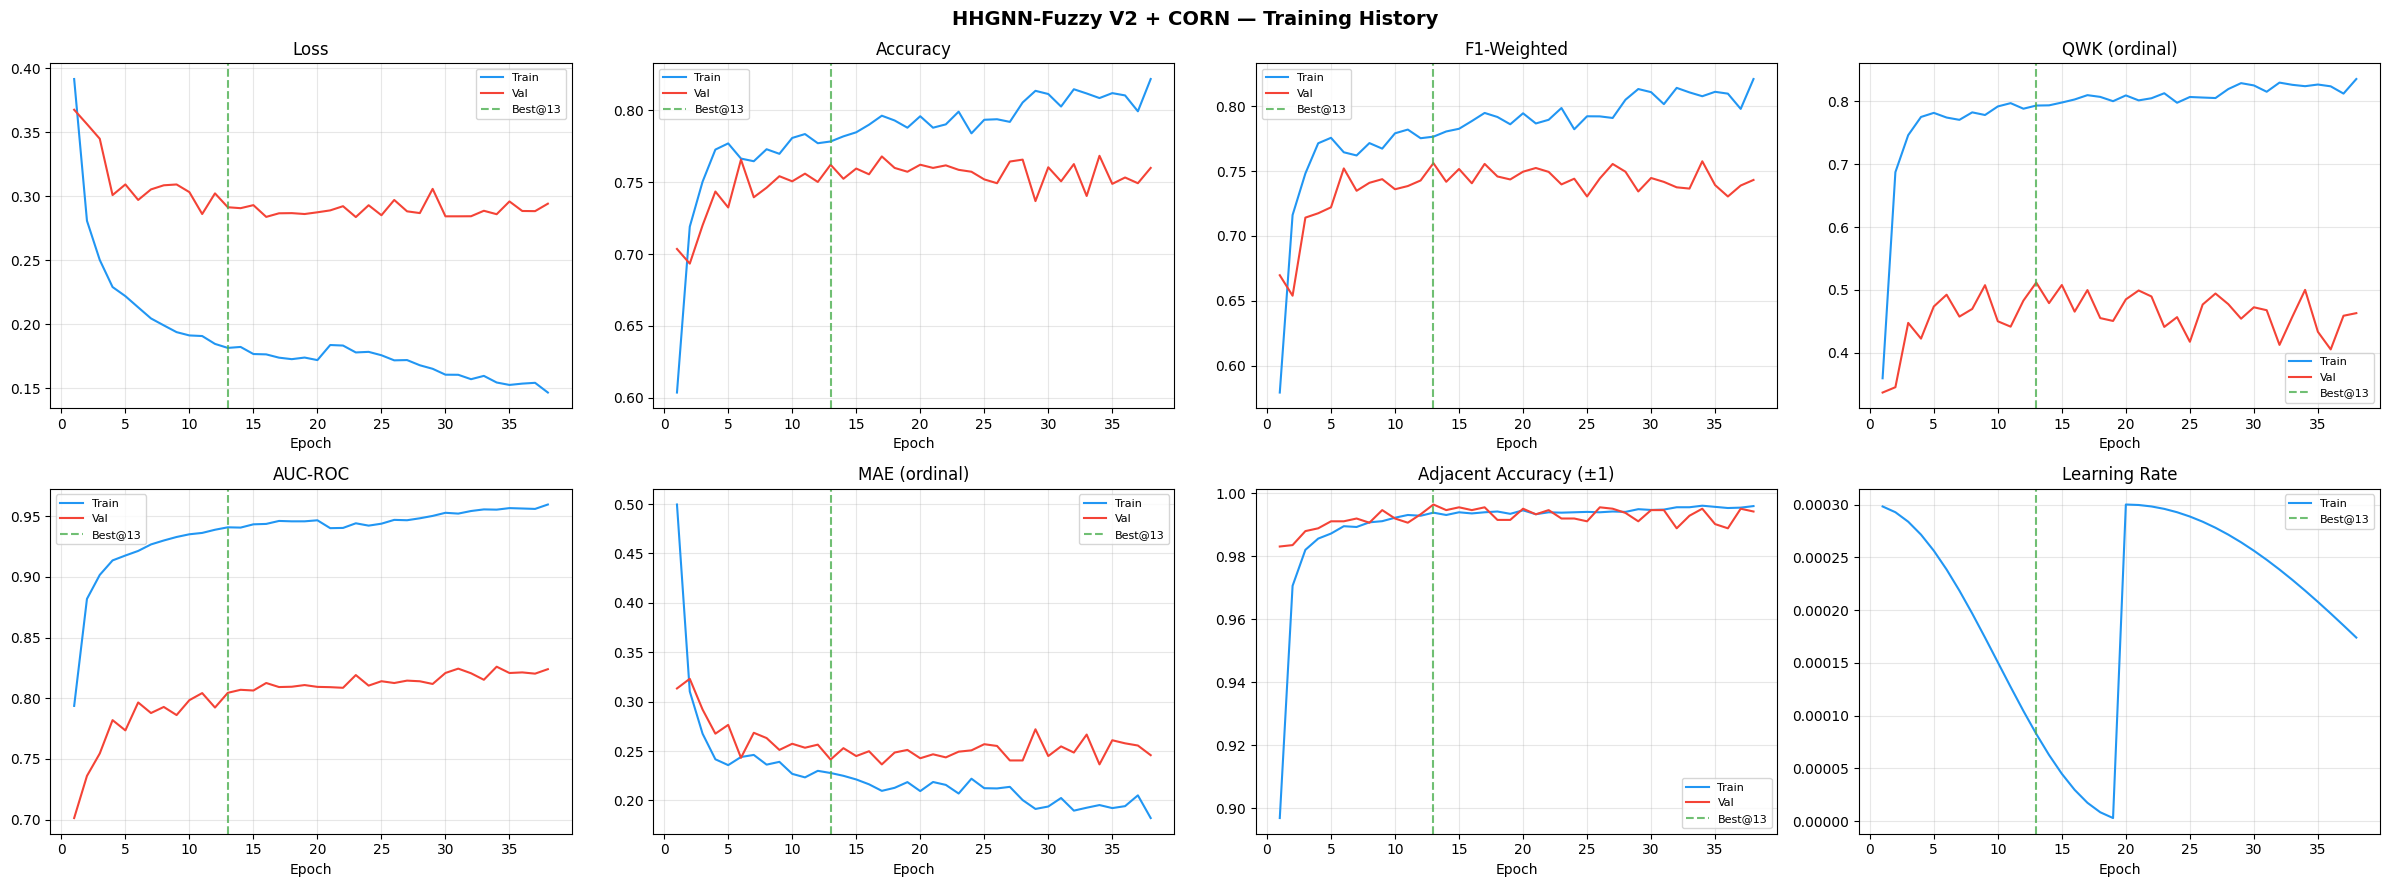

Training curves saved → hhgnn_fuzzy_v2_curves.png


In [ ]:
# ============================================================
# Visualization: Training Curves (Class-0 Aware Monitoring)
# ============================================================

epochs_x = list(range(1, len(history.get('train_loss', [])) + 1))
if len(epochs_x) == 0:
    raise ValueError('history is empty. Run training cell first.')

best_epoch_plot = int(globals().get('best_epoch', -1))

f1_train_key = 'train_f1_weighted' if 'train_f1_weighted' in history else 'train_f1'
f1_val_key = 'val_f1_weighted' if 'val_f1_weighted' in history else 'val_f1'
f1_title = 'F1-Weighted' if f1_train_key == 'train_f1_weighted' else 'F1-Macro'

panels = [
    ('Loss', 'train_loss', 'val_loss'),
    ('Accuracy', 'train_acc', 'val_acc'),
    (f1_title, f1_train_key, f1_val_key),
    ('QWK (ordinal)', 'train_qwk', 'val_qwk'),
    ('Class-0 F1', 'train_c0_f1', 'val_c0_f1'),
    ('Class-0 Recall', 'train_c0_recall', 'val_c0_recall'),
    ('Class-0 Threshold', None, 'val_c0_threshold'),
    ('Learning Rate', 'lr', None),
]

fig, axes = plt.subplots(2, 4, figsize=(24, 9))
fig.suptitle('HHGNN-Fuzzy V2 + Focal-Ordinal - Training History', fontsize=14, fontweight='bold')

for ax, (title, tr_key, vl_key) in zip(axes.flat, panels):
    has_curve = False

    if tr_key is not None and tr_key in history and len(history[tr_key]) > 0:
        tr_color = '#FF8F00' if tr_key == 'lr' else '#2196F3'
        tr_label = 'LR' if tr_key == 'lr' else 'Train'
        ax.plot(epochs_x, history[tr_key], color=tr_color, label=tr_label)
        has_curve = True

    if vl_key is not None and vl_key in history and len(history[vl_key]) > 0:
        vl_color = '#8E24AA' if vl_key == 'val_c0_threshold' else '#F44336'
        vl_label = 'Val-Threshold' if vl_key == 'val_c0_threshold' else 'Val'
        ax.plot(epochs_x, history[vl_key], color=vl_color, label=vl_label)
        has_curve = True

    if best_epoch_plot > 0 and best_epoch_plot <= len(epochs_x):
        ax.axvline(best_epoch_plot, color='#4CAF50', linestyle='--', alpha=0.8, label=f'Best@{best_epoch_plot}')

    ax.set_title(title)
    ax.set_xlabel('Epoch')
    ax.grid(alpha=0.3)

    if has_curve:
        ax.legend(fontsize=8)
    else:
        ax.text(0.5, 0.5, 'N/A', ha='center', va='center', transform=ax.transAxes)

plt.tight_layout()
plt.savefig(ARTIFACT_DIR / 'hhgnn_fuzzy_v2_curves.png', dpi=180, bbox_inches='tight')
plt.show()
print('Training curves saved -> hhgnn_fuzzy_v2_curves.png')

## 14. Visualization: Confusion Matrix & Error Distribution


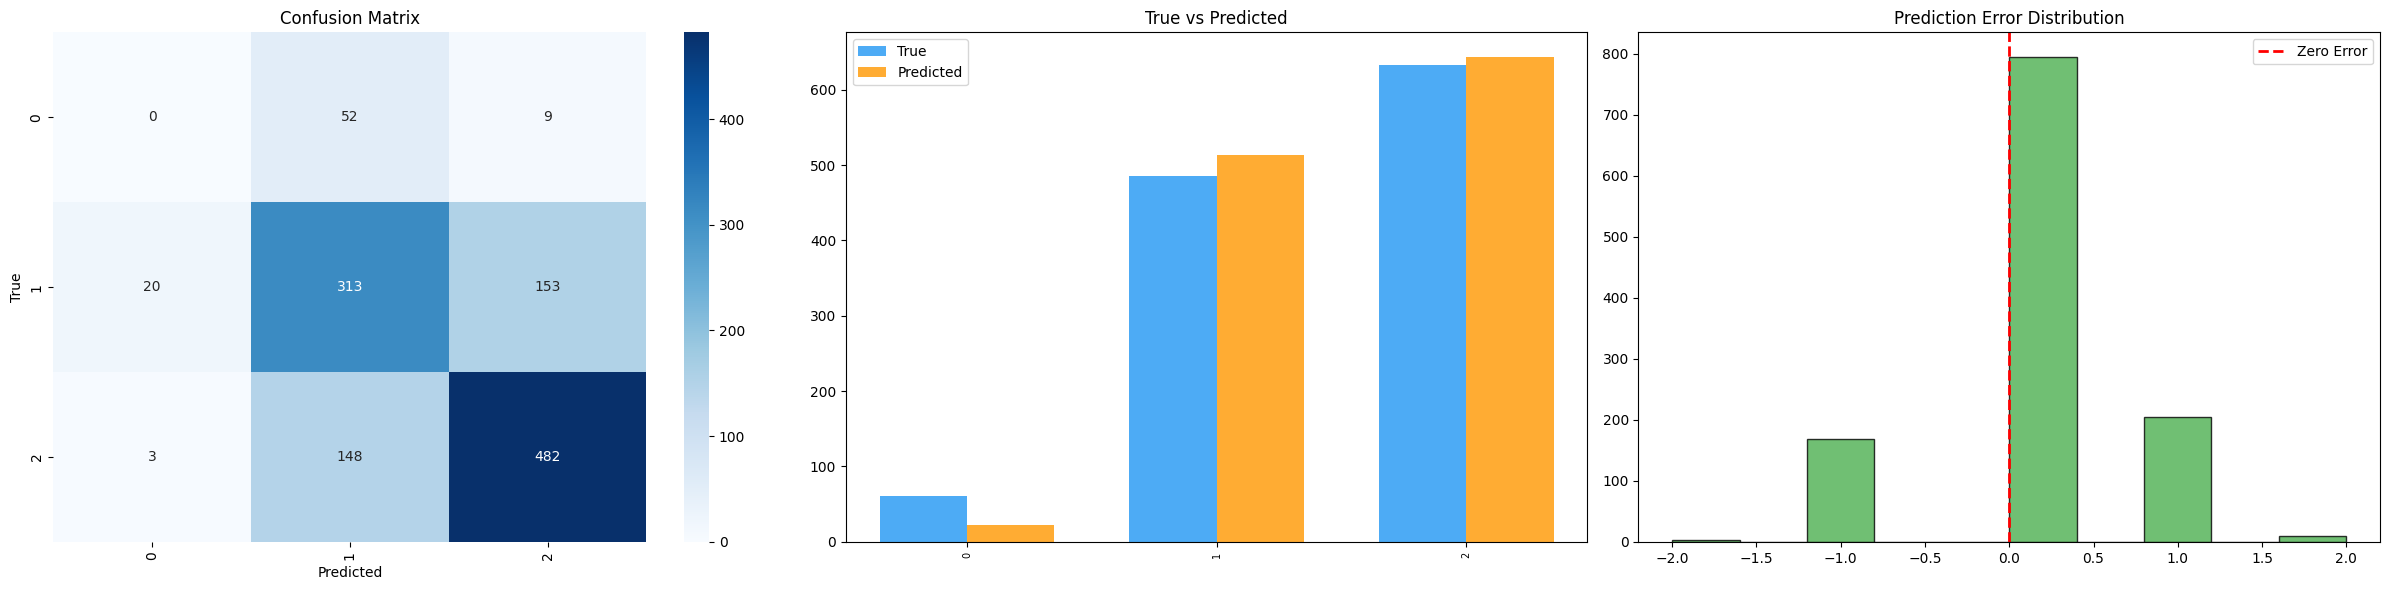

Result plots saved.


In [17]:
# ============================================================
# Confusion Matrix + Error Distribution
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(24, 6))

all_labels = sorted(set(y_true) | set(y_pred))
label_names = [rating_mapping.get(i, str(i)) for i in all_labels]
cm = confusion_matrix(y_true, y_pred, labels=all_labels)

if len(all_labels) <= 25:
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=label_names, yticklabels=label_names, ax=axes[0])
else:
    sns.heatmap(cm, cmap='Blues', ax=axes[0])
axes[0].set_title('Confusion Matrix'); axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('True')
axes[0].tick_params(axis='x', rotation=90)

true_counts = pd.Series(y_true).value_counts().sort_index()
pred_counts = pd.Series(y_pred).value_counts().sort_index()
all_idx = sorted(set(true_counts.index) | set(pred_counts.index))
x_pos = np.arange(len(all_idx))
width = 0.35
axes[1].bar(x_pos - width/2, [true_counts.get(i, 0) for i in all_idx], width, label='True', alpha=0.8, color='#2196F3')
axes[1].bar(x_pos + width/2, [pred_counts.get(i, 0) for i in all_idx], width, label='Predicted', alpha=0.8, color='#FF9800')
axes[1].set_title('True vs Predicted'); axes[1].legend()
if len(all_idx) <= 25:
    axes[1].set_xticks(x_pos)
    axes[1].set_xticklabels([rating_mapping.get(i, str(i)) for i in all_idx], rotation=90, fontsize=7)

errors = y_pred - y_true
axes[2].hist(errors, bins=max(10, len(set(errors))), color='#4CAF50', edgecolor='black', alpha=0.8)
axes[2].set_title('Prediction Error Distribution')
axes[2].axvline(x=0, color='red', linestyle='--', linewidth=2, label='Zero Error'); axes[2].legend()

plt.tight_layout()
plt.savefig(ARTIFACT_DIR / 'hhgnn_results.png', dpi=150, bbox_inches='tight')
plt.show()
print('Result plots saved.')

## 15. xAI: SHAP Explainability

SHAP đã được đồng bộ theo chuẩn tối ưu:
- Hỗ trợ chế độ predicted_class hoặc all_classes.
- Chuẩn hóa output SHAP cho cả list/ndarray và multiclass.
- Xuất đầy đủ global importance, per-sample explanations, và beeswarm plot.

SHAP mode: fast | target: predicted_class
Background: 40 | Explain: 24 samples
nsamples=60
Explaining class index: 1 (1)


  0%|          | 0/24 [00:00<?, ?it/s]

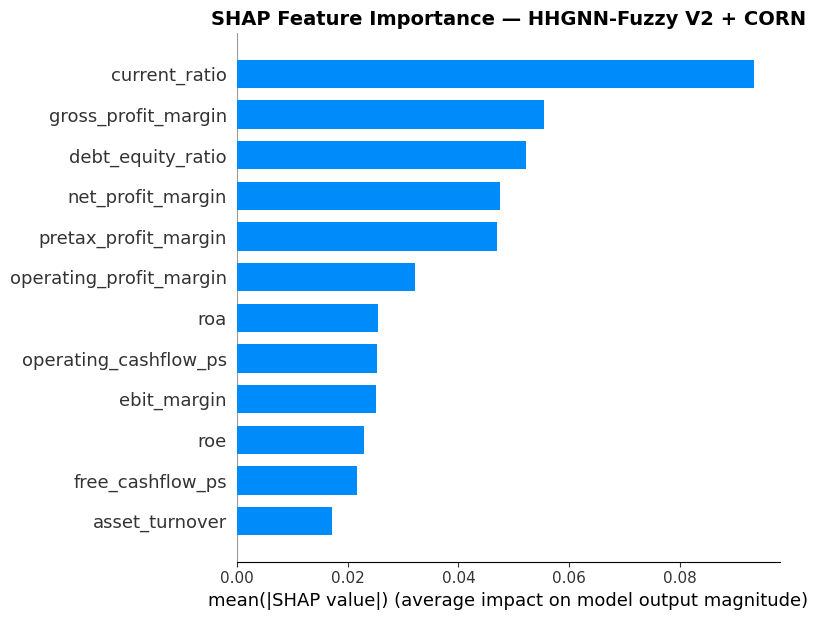

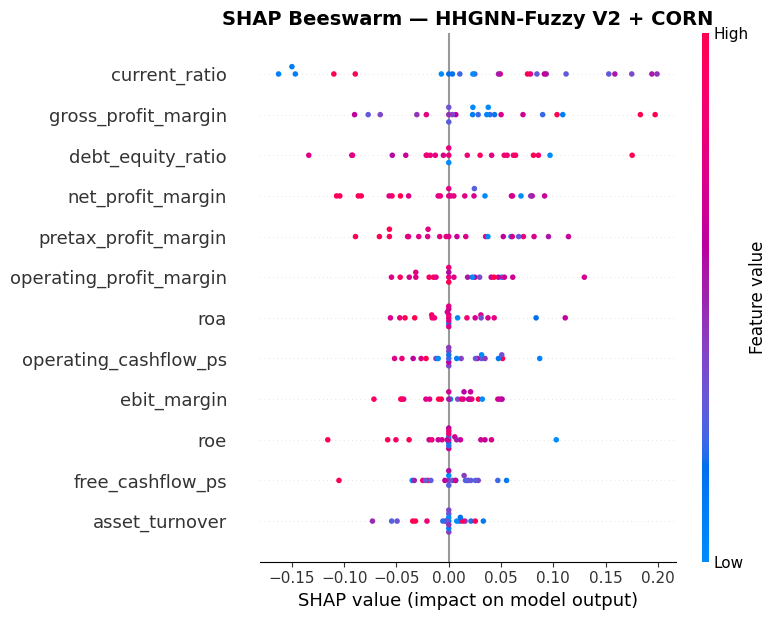

SHAP plots saved to /kaggle/working/credit_rating_artifacts


In [ ]:
# ============================================================
# SHAP Explainability (xAI) - synced + robust output handling
# ============================================================

SHAP_MODE = 'fast'            # {'fast', 'full'}
SHAP_TARGET = 'predicted_class'  # {'predicted_class', 'all_classes'}
SHAP_RANDOM_STATE = SEED

if SHAP_MODE == 'fast':
    SHAP_BACKGROUND_SIZE = 48
    SHAP_MAX_SAMPLES = 24
    SHAP_NSAMPLES = 80
else:
    SHAP_BACKGROUND_SIZE = 120
    SHAP_MAX_SAMPLES = 120
    SHAP_NSAMPLES = 200


def _normalize_shap_output(shap_values, n_classes_expected):
    """
    Return (signed_2d, abs_2d) both with shape (N, F).
    Handles SHAP outputs as list or ndarray for binary/multiclass settings.
    """
    if isinstance(shap_values, list):
        if len(shap_values) == 0:
            raise ValueError('Empty SHAP list output.')
        arr = np.stack([np.asarray(v) for v in shap_values], axis=0)  # (K, N, F)
        signed_2d = arr.mean(axis=0)
        abs_2d = np.mean(np.abs(arr), axis=0)
        return np.asarray(signed_2d), np.asarray(abs_2d)

    arr = np.asarray(shap_values)
    if arr.ndim == 1:
        arr = arr.reshape(1, -1)
        return arr, np.abs(arr)

    if arr.ndim == 2:
        return arr, np.abs(arr)

    if arr.ndim == 3:
        # Common cases: (N, F, K) or (K, N, F)
        if arr.shape[-1] == n_classes_expected:
            signed_2d = arr.mean(axis=2)
            abs_2d = np.mean(np.abs(arr), axis=2)
            return signed_2d, abs_2d
        if arr.shape[0] == n_classes_expected:
            signed_2d = arr.mean(axis=0)
            abs_2d = np.mean(np.abs(arr), axis=0)
            return signed_2d, abs_2d

        # Fallback: average over the first axis
        signed_2d = arr.mean(axis=0)
        abs_2d = np.mean(np.abs(arr), axis=0)
        return signed_2d, abs_2d

    raise ValueError(f'Unsupported SHAP output ndim={arr.ndim}')


class HHGNNWrapperV2:
    """
    Wrap HHGNN-V2 model to accept tabular numpy input for SHAP.
    """

    def __init__(self, model, device, feature_names, train_means: np.ndarray, train_stds: np.ndarray):
        self.model = model
        self.device = device
        self.feature_names = feature_names
        self.train_means = train_means
        self.train_stds = train_stds
        self.model.eval()

    def _to_pyg_batch(self, X_tabular: np.ndarray):
        X_tabular = np.asarray(X_tabular, dtype=np.float32)
        if X_tabular.ndim == 1:
            X_tabular = X_tabular.reshape(1, -1)

        z_tabular = ((X_tabular - self.train_means) / self.train_stds).clip(-3, 3)

        data_list = []
        for i in range(len(X_tabular)):
            edge_index, edge_weight, node_x = build_fuzzy_feature_graph_v2(
                X_tabular[i], z_tabular[i], self.feature_names
            )
            data_list.append(Data(
                x=node_x,
                edge_index=edge_index,
                edge_attr=edge_weight.unsqueeze(1),
            ))

        return Batch.from_data_list(data_list).to(self.device)

    def predict(self, X_tabular: np.ndarray) -> np.ndarray:
        batch = self._to_pyg_batch(X_tabular)
        with torch.inference_mode():
            logits_corn, _ = self.model(batch.x, batch.edge_index, batch.edge_attr, batch.batch)
            probs = corn_to_probs(logits_corn, n_classes).cpu().numpy()
        return probs

    def predict_class_prob(self, X_tabular: np.ndarray, class_idx: int) -> np.ndarray:
        return self.predict(X_tabular)[:, class_idx]


wrapper = HHGNNWrapperV2(
    model=model,
    device=device,
    feature_names=FINANCIAL_FEATURES,
    train_means=train_means,
    train_stds=train_stds,
)

X_test_tab = X_all[test_idx]
y_test_tab = y_all[test_idx].astype(int)
rng = np.random.default_rng(SHAP_RANDOM_STATE)

background_size = int(min(SHAP_BACKGROUND_SIZE, len(train_idx)))
explain_size = int(min(SHAP_MAX_SAMPLES, len(X_test_tab)))

if background_size <= 0 or explain_size <= 0:
    raise ValueError('Not enough samples to run SHAP. Check train/test split cells.')

bg_pick = rng.choice(len(train_idx), size=background_size, replace=False)
ex_pick = rng.choice(len(X_test_tab), size=explain_size, replace=False)

background = X_all[train_idx][bg_pick]
X_shap = X_test_tab[ex_pick]
y_true_shap = y_test_tab[ex_pick]

probs_shap = wrapper.predict(X_shap)
y_pred_shap = probs_shap.argmax(axis=1)
pred_prob_shap = probs_shap[np.arange(explain_size), y_pred_shap]

if SHAP_TARGET == 'predicted_class':
    target_class = int(np.bincount(y_pred_shap, minlength=n_classes).argmax())
    print(f'Explaining predicted class probability for class: {target_class}')
    explainer = shap.KernelExplainer(
        lambda x: wrapper.predict_class_prob(x, target_class),
        background,
    )
    shap_raw = explainer.shap_values(X_shap, nsamples=SHAP_NSAMPLES)
    signed_2d, abs_2d = _normalize_shap_output(shap_raw, n_classes)
else:
    target_class = -1
    print('Explaining all classes and averaging SHAP magnitudes across classes.')
    explainer = shap.KernelExplainer(wrapper.predict, background)
    shap_raw = explainer.shap_values(X_shap, nsamples=SHAP_NSAMPLES)
    signed_2d, abs_2d = _normalize_shap_output(shap_raw, n_classes)

if signed_2d.shape != X_shap.shape:
    raise ValueError(f'SHAP shape mismatch: {signed_2d.shape} vs expected {X_shap.shape}')

rows_feature_imp = []
rows_detail = []

for i in range(explain_size):
    sample_abs = abs_2d[i]
    sample_signed = signed_2d[i]

    for feat, imp in zip(FINANCIAL_FEATURES, sample_abs):
        rows_feature_imp.append({
            'sample_rank': int(i + 1),
            'sample_index': int(ex_pick[i]),
            'y_true': int(y_true_shap[i]),
            'y_pred': int(y_pred_shap[i]),
            'pred_prob': float(pred_prob_shap[i]),
            'target_class_explained': int(target_class),
            'feature': str(feat),
            'mean_abs_shap': float(imp),
        })

    topk = int(min(8, len(FINANCIAL_FEATURES)))
    top_pos = np.argsort(-sample_abs)[:topk]
    for p in top_pos:
        rows_detail.append({
            'sample_rank': int(i + 1),
            'sample_index': int(ex_pick[i]),
            'y_true': int(y_true_shap[i]),
            'y_pred': int(y_pred_shap[i]),
            'pred_prob': float(pred_prob_shap[i]),
            'target_class_explained': int(target_class),
            'feature': str(FINANCIAL_FEATURES[p]),
            'feature_value': float(X_shap[i, p]),
            'shap_value': float(sample_signed[p]),
            'abs_shap_value': float(sample_abs[p]),
        })

shap_feature_df = pd.DataFrame(rows_feature_imp)
shap_detail_df = pd.DataFrame(rows_detail)

if len(shap_feature_df) == 0:
    raise ValueError('No SHAP explanations were generated. Check SHAP settings and rerun.')

shap_global = (
    shap_feature_df.groupby('feature', as_index=False)['mean_abs_shap']
    .mean()
    .sort_values('mean_abs_shap', ascending=False)
    .reset_index(drop=True)
)

shap_feature_path = ARTIFACT_DIR / 'shap_feature_importance.csv'
shap_detail_path = ARTIFACT_DIR / 'shap_sample_explanations.csv'
shap_summary_path = ARTIFACT_DIR / 'shap_summary.png'
shap_beeswarm_path = ARTIFACT_DIR / 'shap_beeswarm.png'

shap_global.to_csv(shap_feature_path, index=False)
shap_detail_df.to_csv(shap_detail_path, index=False)

plt.figure(figsize=(10, 7))
top_plot = shap_global.head(20).iloc[::-1]
plt.barh(top_plot['feature'], top_plot['mean_abs_shap'], color='#006D77')
plt.title('Global SHAP Importance (mean |SHAP|)')
plt.xlabel('mean(|SHAP value|)')
plt.ylabel('Feature')
plt.tight_layout()
plt.savefig(shap_summary_path, dpi=200, bbox_inches='tight')
plt.show()

plt.figure(figsize=(12, 8))
shap.summary_plot(signed_2d, X_shap, feature_names=FINANCIAL_FEATURES, show=False)
plt.title('SHAP Beeswarm - HHGNN-Fuzzy V2 + CORN', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(shap_beeswarm_path, dpi=200, bbox_inches='tight')
plt.show()

print(f'SHAP mode: {SHAP_MODE} | target: {SHAP_TARGET}')
print(f'SHAP explained samples: {explain_size}')
print(f'SHAP background samples: {background_size}')
print(f'SHAP nsamples (KernelExplainer): {SHAP_NSAMPLES}')
print('Top SHAP features (global):')
print(shap_global.head(12).to_string(index=False))
print(f'Saved: {shap_feature_path}')
print(f'Saved: {shap_detail_path}')
print(f'Saved: {shap_summary_path}')
print(f'Saved: {shap_beeswarm_path}')

## 16. Summary

**Model:** HHGNN-Fuzzy V2 + Focal-Ordinal Hybrid (architecture-level fuzzy gate + class-0 expert)

**Highlights:**
- Loss da chuyen sang Hybrid Focal + Ordinal distance voi dynamic scheduling cho class-0.
- Them class-0 expert branch de bo sung bias cho class-0 logit ngay trong kien truc model.
- Threshold class-0 duoc calibration co warmup/interval de giam overfit validation.
- Monitoring da bo sung panel Class-0 F1/Recall/Threshold de theo doi minority learning ro rang hon.

**Artifacts chinh:**
- hhgnn_fuzzy_v2_best_model.pt, hhgnn_fuzzy_v2_best_meta.pt
- hhgnn_fuzzy_v2_metrics.csv
- hhgnn_fuzzy_v2_curves.png, hhgnn_results.png
- shap_feature_importance.csv, shap_sample_explanations.csv
- shap_summary.png, shap_beeswarm.png